# Mushroom Classification
## TAKE-HOME CHALLENGE — MACHINE LEARNING & DEEP LEARNING

### Can Machine Learning Identify Whether a Mushroom is Edible or Poisonous?

**Nama:**  
**NIM:**  
**Jurusan:**  
**Tanggal Pengumpulan:**  

---

## Petunjuk Umum

Notebook ini merupakan template yang harus dilengkapi oleh peserta.

Pada setiap bagian, perhatikan format berikut:

### 📌 TUGAS
Menjelaskan apa yang harus dikerjakan.

### 💡 PETUNJUK
Memberikan arahan atau konsep yang dapat digunakan.

### 💻 Tulis kode kamu di bawah ini
Area untuk menuliskan kode.

### 📝 ANALISIS / INSIGHT
Area untuk menjelaskan hasil yang diperoleh.

> **Catatan:** Jangan hanya menampilkan kode dan output. Berikan penjelasan terhadap hasil analisis dan keputusan yang kamu buat.


# 1. Problem Definition

## 📌 TUGAS

Jawab pertanyaan berikut:

1. Apa permasalahan utama yang ingin diselesaikan?
2. Apakah permasalahan ini termasuk Classification atau Regression?
3. Apa target yang akan diprediksi?
4. Mengapa permasalahan ini termasuk Classification?
5. Apa output yang diharapkan dari model?

## 📝 ANALISIS / JAWABAN

Tuliskan jawaban kamu di bawah ini.


# 2. Import Libraries

## 📌 TUGAS

Import seluruh library yang diperlukan untuk:

- Data manipulation
- Data visualization
- Data preprocessing
- Machine Learning
- Model evaluation
- Hyperparameter tuning
- Deep Learning

## 💡 PETUNJUK

Beberapa library yang mungkin digunakan:

- pandas
- numpy
- matplotlib
- seaborn
- scikit-learn
- tensorflow / keras

## 💻 Tulis kode kamu di bawah ini:


In [11]:
# Import library yang kamu butuhkan di bawah ini

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# Tambahkan library lainnya sesuai kebutuhan


# 3. Load Dataset

## 📌 TUGAS

Load dataset `mushrooms.csv`.

Setelah dataset berhasil dimuat:

1. Tampilkan 5 data pertama.
2. Tampilkan 5 data terakhir.

## 💡 PETUNJUK

Gunakan fungsi seperti:

- `pd.read_csv()`
- `head()`
- `tail()`

## 💻 Tulis kode kamu di bawah ini:


In [12]:
df = pd.read_csv("../dataset/mushrooms.csv")

In [13]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


# 4. Data Understanding

Pada tahap ini, pahami struktur dan karakteristik dataset sebelum melakukan analisis lebih lanjut.


## 4.1 Dataset Shape

### 📌 TUGAS

Tampilkan:

- Jumlah baris
- Jumlah kolom

### 💡 PETUNJUK

Gunakan:

`shape`

### 💻 Tulis kode kamu di bawah ini:


In [14]:
df.shape

(8124, 23)

In [15]:
df.tail()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,o,c,l


In [16]:
df.describe(include="all")

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [17]:
df["class"].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

In [18]:
df["class"].value_counts(normalize=True) * 100

class
e    51.797144
p    48.202856
Name: proportion, dtype: float64

## 4.2 Dataset Information

### 📌 TUGAS

Tampilkan informasi dataset, termasuk:

- Nama kolom
- Tipe data
- Jumlah data
- Informasi non-null

### 💡 PETUNJUK

Gunakan:

- `columns`
- `info()`

### 💻 Tulis kode kamu di bawah ini:


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

## 4.3 Unique Value Analysis

### 📌 TUGAS

Hitung jumlah nilai unik pada setiap kolom.

Kemudian identifikasi:

- Fitur dengan kategori paling banyak.
- Fitur dengan kategori paling sedikit.
- Fitur yang mungkin hanya memiliki satu nilai.

### 💡 PETUNJUK

Gunakan:

- `nunique()`
- `unique()`
- `value_counts()`

### 💻 Tulis kode kamu di bawah ini:


In [20]:
# Jumlah unique value setiap kolom
unique_counts = df.nunique()

print("Jumlah unique value setiap kolom:")
display(unique_counts.sort_values(ascending=False))

print("\nFitur dengan kategori paling banyak:")
print(unique_counts.idxmax(), "=", unique_counts.max(), "kategori")

print("\nFitur dengan kategori paling sedikit:")
print(unique_counts.idxmin(), "=", unique_counts.min(), "kategori")

print("\nFitur yang hanya memiliki satu nilai:")
print(unique_counts[unique_counts == 1])

Jumlah unique value setiap kolom:


gill-color                  12
cap-color                   10
odor                         9
stalk-color-below-ring       9
spore-print-color            9
stalk-color-above-ring       9
habitat                      7
cap-shape                    6
population                   6
stalk-root                   5
ring-type                    5
stalk-surface-above-ring     4
veil-color                   4
stalk-surface-below-ring     4
cap-surface                  4
ring-number                  3
gill-attachment              2
class                        2
bruises                      2
gill-size                    2
gill-spacing                 2
stalk-shape                  2
veil-type                    1
dtype: int64


Fitur dengan kategori paling banyak:
gill-color = 12 kategori

Fitur dengan kategori paling sedikit:
veil-type = 1 kategori

Fitur yang hanya memiliki satu nilai:
veil-type    1
dtype: int64


## 4.4 Dataset Summary

### 📌 TUGAS

Tampilkan ringkasan statistik atau ringkasan kategorikal dari dataset.

### 💡 PETUNJUK

Karena dataset didominasi data kategorikal, pertimbangkan penggunaan:

`describe(include="all")`

### 💻 Tulis kode kamu di bawah ini:


In [21]:
## 4.4 Dataset Summary

summary = df.describe(include="all")

display(summary)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


## 4.5 Target Analysis

### 📌 TUGAS

Identifikasi:

- Feature / Input (X)
- Target / Output (y)

Target utama pada dataset adalah:

`class`

Cari tahu kategori apa saja yang terdapat pada target.

### 💻 Tulis kode kamu di bawah ini:


In [22]:
# Menentukan Feature (X) dan Target (y)

X = df.drop(columns=["class"])
y = df["class"]

print("Feature (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.name)

print("\nKategori pada target:")
print(y.unique())

Feature (X):
['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

Target (y):
class

Kategori pada target:
<StringArray>
['p', 'e']
Length: 2, dtype: str


# 5. Exploratory Data Analysis (EDA)

Pada tahap ini, lakukan eksplorasi data menggunakan visualisasi.

> Setiap visualisasi penting harus disertai dengan interpretasi.


## 5.1 Target Distribution

### 📌 TUGAS

Visualisasikan distribusi target `class`.

Analisis:

1. Berapa jumlah Edible?
2. Berapa jumlah Poisonous?
3. Apakah dataset balanced atau imbalanced?

### 💡 PETUNJUK

Gunakan salah satu atau beberapa:

- Count Plot
- Bar Chart
- Pie Chart

### 💻 Tulis kode kamu di bawah ini:


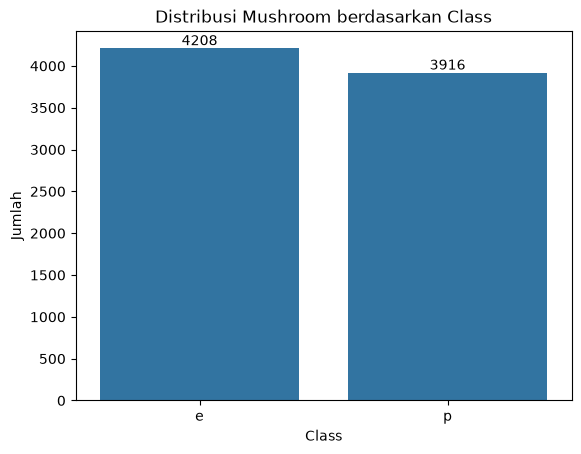

In [23]:
target_counts = df["class"].value_counts()

sns.barplot(
    x=target_counts.index,
    y=target_counts.values
)

plt.title("Distribusi Mushroom berdasarkan Class")
plt.xlabel("Class")
plt.ylabel("Jumlah")

for i, value in enumerate(target_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.show()

### 📝 ANALISIS / INSIGHT
### 📊 Analisis Distribusi Target

Berdasarkan visualisasi distribusi `class`, dataset mushroom terdiri dari dua kategori, yaitu:

- **Edible (`e`)** sebanyak **4.208 data**
- **Poisonous (`p`)** sebanyak **3.916 data**

Dari hasil tersebut, jumlah data pada kedua kelas relatif berdekatan. Kelas **Edible** memiliki jumlah data sedikit lebih banyak dibandingkan kelas **Poisonous**.

Dengan demikian, dataset dapat dikatakan **relatif balanced (seimbang)** karena tidak terdapat perbedaan jumlah data yang sangat besar antara kedua kelas. Kondisi ini cukup baik untuk proses klasifikasi karena model tidak terlalu didominasi oleh salah satu kelas.

**Insight:**
1. Kelas `e` (Edible) merupakan kelas dengan jumlah data terbanyak, yaitu 4.208 data.
2. Kelas `p` (Poisonous) memiliki 3.916 data.
3. Selisih jumlah kedua kelas adalah **292 data**, sehingga distribusi target masih relatif seimbang.
4. Karena distribusi target cukup seimbang, penggunaan `stratify=y` pada proses **train-test split** dapat membantu mempertahankan proporsi kedua kelas pada data training dan testing.

## 5.2 Feature Distribution

### 📌 TUGAS

Pilih minimal **5 fitur** untuk dianalisis.

Rekomendasi:

- odor
- bruises
- gill-size
- cap-color
- habitat

Visualisasikan distribusi setiap fitur yang dipilih.

### 💻 Tulis kode kamu di bawah ini:


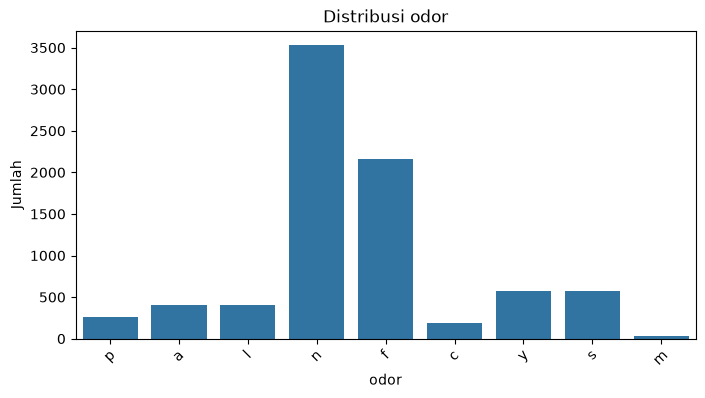

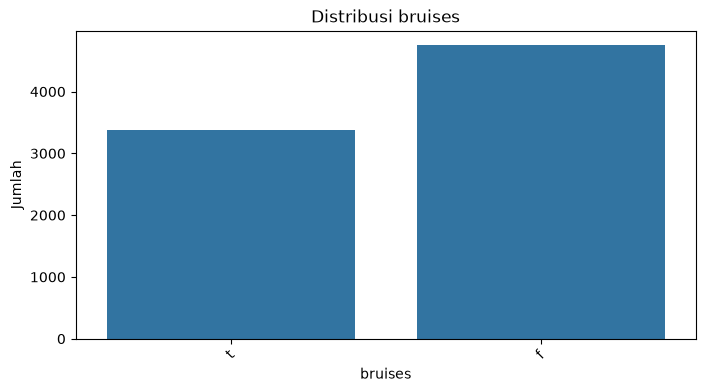

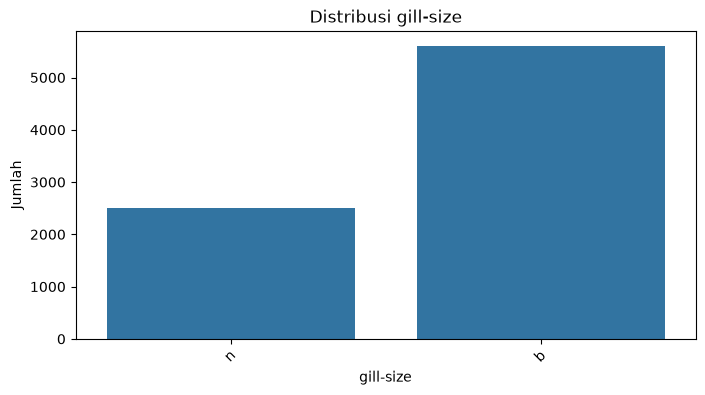

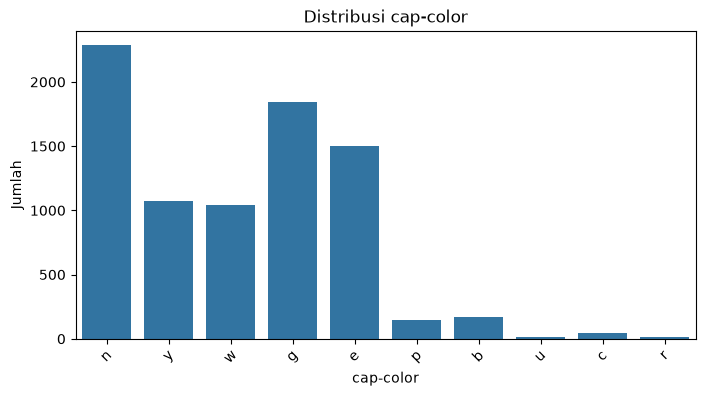

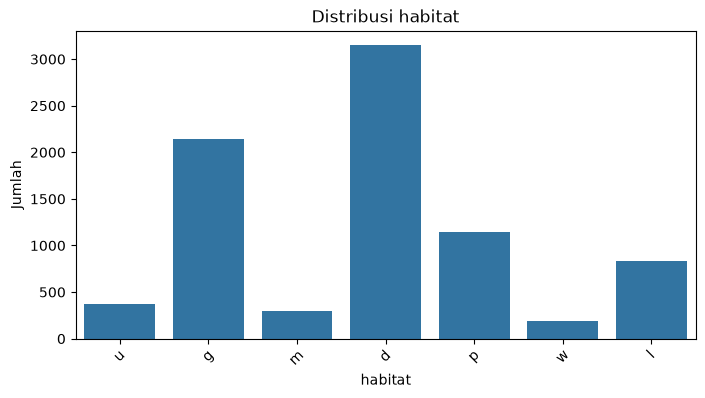

In [24]:
# Fitur yang akan dianalisis
features = [
    "odor",
    "bruises",
    "gill-size",
    "cap-color",
    "habitat"
]

# Visualisasi distribusi setiap fitur
for feature in features:
    plt.figure(figsize=(8, 4))
    
    sns.countplot(data=df, x=feature)
    
    plt.title(f"Distribusi {feature}")
    plt.xlabel(feature)
    plt.ylabel("Jumlah")
    plt.xticks(rotation=45)
    
    plt.show()

### 📝 ANALISIS / INSIGHT

### 📊 Analisis Distribusi Feature

Pada tahap ini dilakukan analisis distribusi terhadap beberapa fitur kategorikal, yaitu `bruises`, `gill-size`, `cap-color`, dan `habitat`. Analisis ini bertujuan untuk mengetahui kategori yang paling dominan pada masing-masing fitur sebelum melihat hubungannya dengan target `class`.

**Insight yang diperoleh:**

1. **Bruises**
   
   Distribusi fitur `bruises` menunjukkan bahwa kategori **f** memiliki jumlah data lebih banyak dibandingkan kategori **t**. Hal ini menunjukkan bahwa sebagian besar sampel pada dataset berada pada kategori `f` (tidak memiliki bruises).

2. **Gill-size**
   
   Pada fitur `gill-size`, kategori **b** memiliki jumlah data yang jauh lebih banyak dibandingkan kategori **n**. Artinya, ukuran insang pada dataset lebih banyak berada pada kategori `b`.

3. **Cap-color**
   
   Distribusi `cap-color` menunjukkan bahwa beberapa kategori memiliki jumlah data yang jauh lebih dominan dibandingkan kategori lainnya. Kategori **n** merupakan salah satu kategori dengan jumlah terbanyak, sedangkan beberapa kategori lainnya hanya memiliki jumlah sampel yang relatif sedikit. Hal ini menunjukkan bahwa distribusi warna tudung tidak merata pada seluruh kategori.

4. **Habitat**
   
   Pada fitur `habitat`, kategori **d** memiliki jumlah data paling dominan, diikuti oleh kategori **g** dan **p**. Sementara itu, beberapa kategori lainnya memiliki jumlah data yang jauh lebih sedikit. Dengan demikian, distribusi habitat pada dataset juga tidak merata.

### 💡 Kesimpulan Sementara

Dari distribusi fitur tersebut terlihat bahwa beberapa kategori memiliki jumlah sampel yang jauh lebih dominan dibandingkan kategori lainnya. Namun, distribusi ini **belum dapat digunakan untuk menentukan apakah suatu kategori berkaitan dengan jamur Edible atau Poisonous**.

Untuk mengetahui hubungan tersebut, diperlukan analisis lanjutan berupa **Feature vs Target**, khususnya `odor vs class`, `bruises vs class`, `gill-size vs class`, dan `habitat vs class`.

## 5.3 Feature vs Target

### 📌 TUGAS

Analisis hubungan antara fitur dengan target `class`.

Minimal analisis:

- odor vs class
- bruises vs class
- gill-size vs class
- habitat vs class

Kamu dapat menambahkan fitur lain jika diperlukan.

### 💡 PETUNJUK

Gunakan visualisasi yang dapat menunjukkan hubungan antara kategori fitur dan target.

### 💻 Tulis kode kamu di bawah ini:


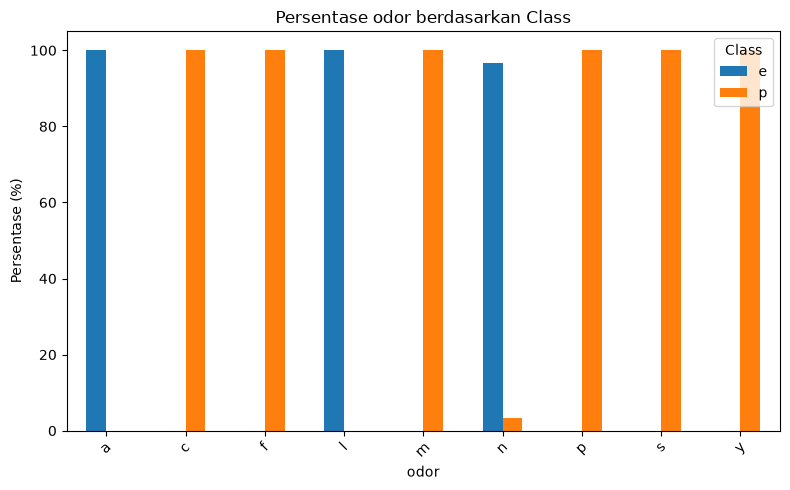

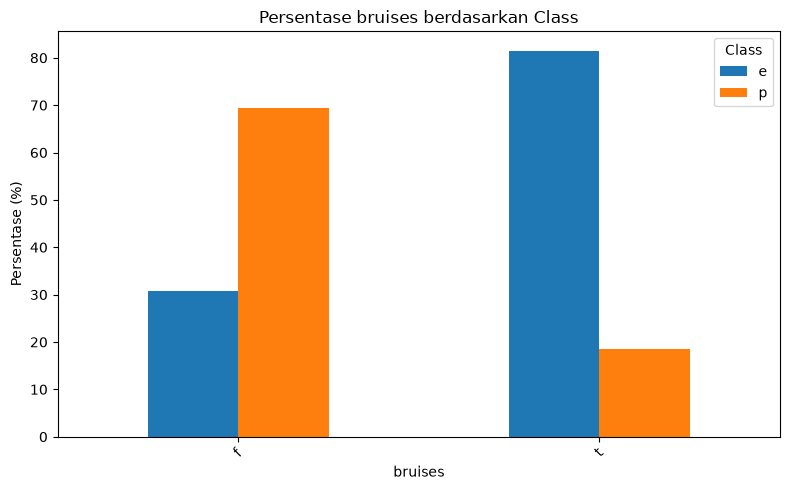

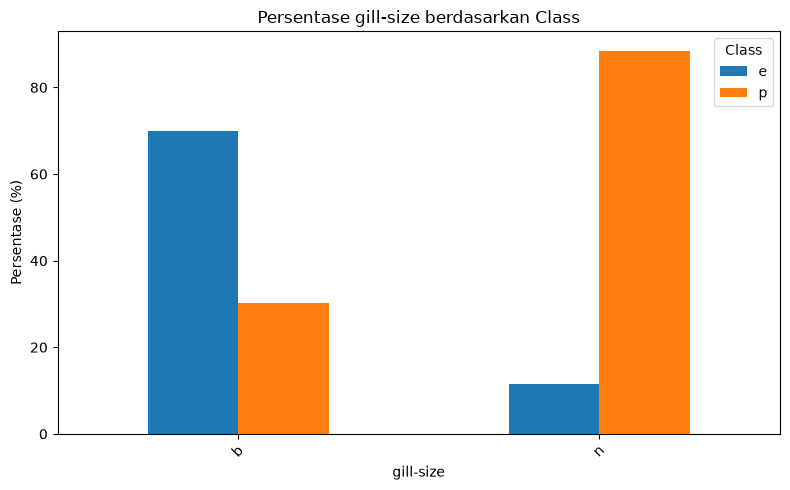

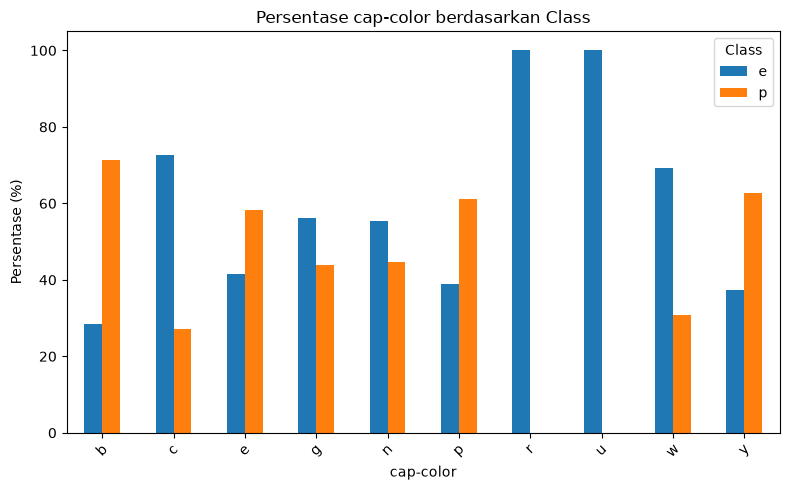

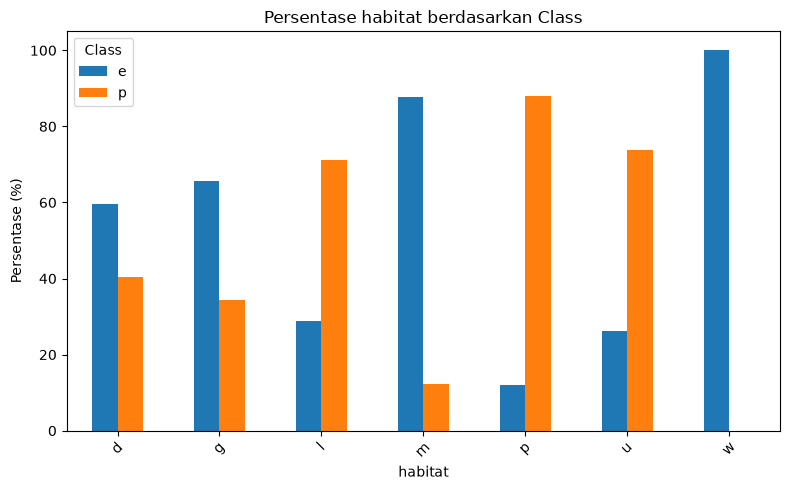

In [25]:
for feature in features:
    cross_tab = pd.crosstab(
        df[feature],
        df["class"],
        normalize="index"
    ) * 100

    cross_tab.plot(
        kind="bar",
        figsize=(8, 5)
    )

    plt.title(f"Persentase {feature} berdasarkan Class")
    plt.xlabel(feature)
    plt.ylabel("Persentase (%)")
    plt.xticks(rotation=45)
    plt.legend(title="Class")

    plt.tight_layout()
    plt.show()

### 📝 ANALISIS / INSIGHT

Tuliskan minimal 3 insight berdasarkan hubungan antara fitur dan target.

Contoh pertanyaan yang dapat dijawab:

- Apakah terdapat fitur yang memiliki hubungan kuat dengan class?
- Apakah kategori tertentu lebih sering muncul pada Poisonous?
- Apakah terdapat pola yang menarik?


### 📝 Analisis / Insight

Berdasarkan analisis hubungan antara beberapa fitur dengan target `class`, terdapat beberapa pola yang cukup kuat antara karakteristik mushroom dengan kelas Edible (`e`) dan Poisonous (`p`).

1. **Fitur `odor` memiliki hubungan yang sangat kuat dengan `class`.**  
   Beberapa kategori pada `odor` terlihat hampir atau bahkan sepenuhnya didominasi oleh salah satu kelas. Terdapat kategori odor yang didominasi oleh **Edible**, sementara beberapa kategori lainnya didominasi oleh **Poisonous**. Hal ini menunjukkan bahwa karakteristik bau merupakan salah satu fitur yang sangat informatif untuk membedakan mushroom berdasarkan kelasnya.

2. **Fitur `gill-size` menunjukkan perbedaan yang cukup jelas antara Edible dan Poisonous.**  
   Pada kategori `b`, sebagian besar data termasuk kelas **Edible**, sedangkan pada kategori `n`, sebagian besar data termasuk kelas **Poisonous**. Perbedaan proporsi yang cukup besar ini menunjukkan bahwa `gill-size` memiliki hubungan yang cukup kuat dengan target `class`.

3. **Fitur `bruises` juga menunjukkan pola yang menarik.**  
   Pada kategori `t`, sebagian besar mushroom termasuk kelas **Edible**, sedangkan pada kategori `f`, proporsi **Poisonous** terlihat lebih besar. Dengan demikian, keberadaan atau tidaknya bruises dapat memberikan informasi yang berguna dalam membedakan kedua kelas.

4. **Fitur `habitat` memiliki pola yang berbeda-beda pada setiap kategorinya.**  
   Beberapa kategori habitat lebih banyak didominasi oleh Edible, sedangkan kategori lainnya lebih banyak didominasi oleh Poisonous. Hal ini menunjukkan bahwa lokasi atau habitat tempat mushroom ditemukan juga memiliki hubungan dengan kelas mushroom, meskipun kekuatannya berbeda antar kategori.

### 💡 Kesimpulan

Dari beberapa fitur yang dianalisis, `odor` menunjukkan pola hubungan yang paling kuat dengan `class`, diikuti oleh `gill-size` dan `bruises`. Beberapa kategori tertentu memiliki dominasi kelas yang sangat jelas, sehingga fitur-fitur tersebut berpotensi menjadi fitur penting dalam membangun model klasifikasi.

Namun, hubungan pada visualisasi ini **tidak berarti bahwa satu fitur secara langsung menyebabkan mushroom menjadi poisonous atau edible**. Visualisasi hanya menunjukkan hubungan atau pola pada dataset. Pengaruh fitur selanjutnya perlu dikonfirmasi melalui proses pemodelan Machine Learning dan evaluasi feature importance.

# 6. Data Preprocessing

## 6.1 Missing Value Analysis

### 📌 TUGAS

Periksa apakah terdapat missing value pada dataset.

Periksa:

1. Missing value standar.
2. Nilai khusus yang mungkin merepresentasikan missing value, seperti `?`.

### 💡 PETUNJUK

Pertimbangkan penggunaan:

- `isnull()`
- `sum()`

Untuk nilai tertentu, kamu dapat melakukan pemeriksaan menggunakan perbandingan terhadap nilai tersebut.

### 💻 Tulis kode kamu di bawah ini:


In [26]:
# Mengubah nilai '?' menjadi NaN
df["stalk-root"] = df["stalk-root"].replace("?", np.nan)

# Mengisi missing value dengan modus
stalk_root_mode = df["stalk-root"].mode()[0]
df["stalk-root"] = df["stalk-root"].fillna(stalk_root_mode)

# Cek kembali missing value
print("Missing value setelah preprocessing:")
print(df["stalk-root"].isnull().sum())

Missing value setelah preprocessing:
0


### 📝 ANALISIS

Jawab:

1. Apakah terdapat missing value?
2. Apakah terdapat nilai `?`?
3. Bagaimana kamu menangani missing value?
4. Mengapa kamu memilih metode tersebut?


## 📝 ANALISIS

Berdasarkan hasil pemeriksaan missing value, diperoleh beberapa temuan:

1. **Apakah terdapat missing value?**  
   Berdasarkan hasil `df.isnull().sum()`, tidak terdapat missing value standar pada dataset. Semua kolom memiliki nilai `0` untuk missing value.

2. **Apakah terdapat nilai `?`?**  
   Ya, terdapat nilai `?` sebanyak **2.480 data** pada fitur `stalk-root`. Nilai `?` pada dataset perlu dianggap sebagai missing value khusus karena bukan merupakan kategori atau nilai sebenarnya dari fitur tersebut.

3. **Bagaimana cara menangani missing value?**  
   Nilai `?` pada `stalk-root` akan diubah menjadi `NaN`, kemudian missing value tersebut akan ditangani dengan mengisi menggunakan **modus (nilai yang paling sering muncul)** pada kolom `stalk-root`.

4. **Mengapa memilih metode tersebut?**  
   Fitur `stalk-root` merupakan fitur kategorikal, sehingga penggunaan mean atau median tidak sesuai. Modus dipilih karena dapat mempertahankan jumlah data dan menggantikan nilai yang hilang dengan kategori yang paling umum pada fitur tersebut.

### 💡 Kesimpulan

Dataset tidak memiliki missing value standar, tetapi terdapat **2.480 nilai khusus `?` pada `stalk-root`** yang perlu diperlakukan sebagai missing value. Karena `stalk-root` merupakan data kategorikal, metode imputasi menggunakan **modus** dipilih untuk menangani nilai tersebut tanpa mengurangi jumlah observasi dalam dataset.

## 6.2 Duplicate Data

### 📌 TUGAS

Periksa apakah terdapat duplicate data.

Hitung:

- Jumlah duplicate.
- Persentase duplicate.

### 💡 PETUNJUK

Gunakan fungsi yang relevan untuk memeriksa duplicate data.

### 💻 Tulis kode kamu di bawah ini:


In [27]:
# Menghitung jumlah data duplikat
duplicate_count = df.duplicated().sum()

# Menghitung persentase data duplikat
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Jumlah duplicate data:", duplicate_count)
print("Persentase duplicate data:", duplicate_percentage, "%")

Jumlah duplicate data: 0
Persentase duplicate data: 0.0 %


### 📝 ANALISIS

Jawab:

> Apakah duplicate data perlu dihapus?

Jelaskan keputusan kamu.


### 📝 Analisis

Duplicate data tidak perlu dihapus karena berdasarkan hasil pemeriksaan tidak ditemukan adanya data yang duplikat pada dataset.

Jumlah duplicate data adalah **0**, sehingga seluruh baris data dapat dipertahankan dan tidak diperlukan proses penghapusan duplicate.

Keputusan ini diambil untuk mempertahankan seluruh informasi yang tersedia dalam dataset tanpa menghilangkan data yang valid.

## 6.3 Constant / Uninformative Feature

### 📌 TUGAS

Periksa apakah terdapat fitur yang:

- Hanya memiliki satu nilai.
- Tidak memiliki variasi.
- Berpotensi tidak memberikan informasi kepada model.

Jika terdapat fitur tersebut, tentukan apakah fitur perlu dihapus.

### 💻 Tulis kode kamu di bawah ini:


In [28]:
# Cek jumlah nilai unik pada setiap fitur
unique_counts = df.nunique()

print("=== Jumlah Nilai Unik Setiap Fitur ===")
print(unique_counts)

# Mencari fitur yang hanya memiliki satu nilai
constant_features = unique_counts[unique_counts <= 1].index.tolist()

print("\n=== Constant / Uninformative Feature ===")
if constant_features:
    print("Fitur yang hanya memiliki satu nilai:")
    print(constant_features)
else:
    print("Tidak terdapat fitur yang hanya memiliki satu nilai.")

=== Jumlah Nilai Unik Setiap Fitur ===
class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   4
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

=== Constant / Uninformative Feature ===
Fitur yang hanya memiliki satu nilai:
['veil-type']


### 📝 ANALISIS

Jelaskan:

- Fitur apa yang ditemukan?
- Apa keputusan yang kamu ambil?
- Mengapa?


### 📝 ANALISIS

Berdasarkan pemeriksaan jumlah nilai unik pada setiap fitur, ditemukan satu fitur yang hanya memiliki satu nilai, yaitu:

- **`veil-type`** → hanya memiliki **1 nilai unik**.

Fitur `veil-type` termasuk **constant / uninformative feature** karena seluruh data memiliki nilai yang sama. Fitur yang tidak memiliki variasi tidak dapat membantu model dalam membedakan kelas `Edible` dan `Poisonous`.

### 📌 Keputusan

Fitur `veil-type` akan **dihapus dari dataset** karena tidak memberikan informasi yang berguna untuk proses klasifikasi.

### 💡 Alasan

Fitur dengan hanya satu nilai tidak memiliki variasi sehingga tidak memiliki daya diskriminasi terhadap target. Mempertahankan fitur tersebut hanya menambah jumlah fitur tanpa memberikan informasi tambahan kepada model. Oleh karena itu, penghapusan `veil-type` dapat membuat dataset menjadi lebih sederhana tanpa kehilangan informasi yang relevan.

## 6.4 Feature Encoding

### 📌 TUGAS

Karena dataset terdiri dari data kategorikal, lakukan encoding terhadap:

- Feature
- Target jika diperlukan

### 💡 PETUNJUK

Kamu dapat mempertimbangkan:

- One Hot Encoding
- Label Encoding
- Ordinal Encoding

### 💻 Tulis kode kamu di bawah ini:


In [29]:
# Pisahkan feature dan target
X = df.drop(columns=["class"])
y = df["class"]

# Encoding target
# e = Edible, p = Poisonous
y = y.map({
    "e": 0,
    "p": 1,
})

# One-Hot Encoding untuk seluruh feature kategorikal
X_encoded = pd.get_dummies(
    X,
    drop_first=False,
    dtype=int,
)

print("Ukuran feature sebelum encoding :", X.shape)
print("Ukuran feature setelah encoding :", X_encoded.shape)

print("\nContoh hasil encoding:")
display(X_encoded.head())

print("\nTarget setelah encoding:")
print(y.head())

Ukuran feature sebelum encoding : (8124, 22)
Ukuran feature setelah encoding : (8124, 116)

Contoh hasil encoding:


,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0,0,0,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
2,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,1,0,0,0,1,...,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0



Target setelah encoding:
0    1
1    0
2    0
3    1
4    0
Name: class, dtype: int64


### 📝 ANALISIS

Jelaskan:

1. Metode encoding yang digunakan.
2. Mengapa metode tersebut dipilih.
3. Apakah encoding dilakukan sebelum atau setelah Train Test Split?
4. Bagaimana kamu mencegah data leakage?


### 📝 ANALISIS

1. **Metode encoding yang digunakan**

   Metode encoding yang digunakan adalah **One-Hot Encoding** untuk fitur dan pemetaan biner untuk target `class`.

   Pada fitur kategorikal, setiap kategori diubah menjadi kolom biner dengan nilai `0` dan `1`. Sedangkan target `class` diubah menjadi:
   
   - `e` = 0 (Edible)
   - `p` = 1 (Poisonous)

2. **Mengapa metode tersebut dipilih?**

   One-Hot Encoding dipilih karena fitur pada dataset mushroom sebagian besar merupakan data kategorikal dan tidak memiliki urutan atau tingkatan tertentu. Dengan One-Hot Encoding, setiap kategori direpresentasikan sebagai fitur terpisah tanpa memberikan makna bahwa suatu kategori lebih besar atau lebih kecil dari kategori lainnya.

   Untuk target digunakan encoding biner karena `class` hanya memiliki dua kategori, yaitu Edible dan Poisonous.

3. **Apakah encoding dilakukan sebelum atau setelah Train-Test Split?**

   Untuk proses modeling, **Train-Test Split dilakukan terlebih dahulu**, kemudian proses encoding dilakukan dengan cara melakukan `fit` encoder hanya pada data training dan menggunakan encoder tersebut untuk melakukan transformasi pada data training dan testing.

   Urutannya adalah:

   `Dataset → Train-Test Split → Fit Encoder pada Training → Transform Training & Testing`

4. **Bagaimana mencegah data leakage?**

   Data leakage dicegah dengan **tidak melakukan fitting encoder menggunakan data testing**. Encoder hanya mempelajari kategori dari data training. Setelah itu, encoder yang sama digunakan untuk mentransformasi data testing.

   Dengan cara tersebut, informasi dari data testing tidak digunakan selama proses training model, sehingga hasil evaluasi model menjadi lebih objektif.

# 7. Feature & Target Preparation

## 📌 TUGAS

Pisahkan:

### Feature (X)

Seluruh fitur yang digunakan sebagai input model.

### Target (y)

Kolom:

`class`

Jika diperlukan, lakukan encoding terhadap target.

## 💻 Tulis kode kamu di bawah ini:


In [30]:
# Memisahkan feature dan target

# Feature (X)
X = df.drop(columns=["class"])

# Target (y)
y = df["class"]

# Encoding target
# e = Edible → 0
# p = Poisonous → 1
y = y.map({
    "e": 0,
    "p": 1,
})

# Menampilkan hasil
print("Shape Feature (X):", X.shape)
print("Shape Target (y):", y.shape)

print("\nFeature (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Shape Feature (X): (8124, 22)
Shape Target (y): (8124,)

Feature (X):


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g



Target (y):


0    1
1    0
2    0
3    1
4    0
Name: class, dtype: int64

# 8. Train Test Split

## 📌 TUGAS

Pisahkan dataset menjadi:

- Training Data
- Testing Data

Gunakan pembagian yang wajar.

Contoh:

- 80% Training
- 20% Testing

Gunakan `random_state` agar eksperimen dapat direproduksi.

Pertimbangkan penggunaan:

`stratify=y`

## 💻 Tulis kode kamu di bawah ini:


In [31]:
from sklearn.model_selection import train_test_split

# Membagi dataset menjadi 80% data training dan 20% data testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Menampilkan ukuran masing-masing data
print("Ukuran data:")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

# Mengecek proporsi kelas
print("\nProporsi class pada data training:")
print(y_train.value_counts(normalize=True))

print("\nProporsi class pada data testing:")
print(y_test.value_counts(normalize=True))

Ukuran data:
X_train : (6499, 22)
X_test  : (1625, 22)
y_train : (6499,)
y_test  : (1625,)

Proporsi class pada data training:
class
0    0.517926
1    0.482074
Name: proportion, dtype: float64

Proporsi class pada data testing:
class
0    0.518154
1    0.481846
Name: proportion, dtype: float64


### 📝 ANALISIS

Jelaskan:

1. Mengapa menggunakan pembagian tersebut?
2. Mengapa menggunakan random_state?
3. Apakah menggunakan stratify?
4. Mengapa?


### 📝 ANALISIS

1. **Mengapa menggunakan pembagian 80% training dan 20% testing?**

   Dataset dibagi menjadi 80% data training dan 20% data testing karena pembagian ini merupakan proporsi yang umum digunakan dalam Machine Learning. Sebagian besar data digunakan untuk melatih model agar model dapat mempelajari pola dari dataset, sedangkan 20% sisanya digunakan untuk menguji kemampuan model pada data yang belum pernah dilihat sebelumnya.

   Pada hasil pembagian, terdapat **6.499 data training** dan **1.625 data testing** dari total **8.124 data**.

2. **Mengapa menggunakan `random_state`?**

   `random_state=42` digunakan agar proses pembagian dataset dapat direproduksi. Artinya, ketika kode dijalankan kembali dengan nilai `random_state` yang sama, pembagian data akan tetap konsisten.

   Hal ini memudahkan proses eksperimen dan perbandingan model karena model selalu menggunakan pembagian data yang sama.

3. **Apakah menggunakan `stratify`?**

   Ya, proses `train_test_split` menggunakan `stratify=y`.

   Penggunaan `stratify=y` bertujuan untuk mempertahankan proporsi kelas `Edible` dan `Poisonous` pada data training dan testing.

4. **Mengapa menggunakan `stratify=y`?**

   `stratify=y` digunakan agar distribusi target tetap seimbang setelah dilakukan pembagian dataset.

   Berdasarkan hasil pembagian:

   - **Training:** class 0 = 51,79% dan class 1 = 48,21%
   - **Testing:** class 0 = 51,82% dan class 1 = 48,18%

   Proporsi kedua kelas pada training dan testing sangat mirip dengan dataset awal. Dengan demikian, tidak ada kelas yang terlalu dominan pada salah satu subset data.

### 💡 Kesimpulan

Pembagian dataset **80:20 dengan `random_state=42` dan `stratify=y`** dianggap sesuai untuk penelitian ini. Data training digunakan untuk mempelajari pola, sedangkan data testing digunakan untuk mengevaluasi kemampuan generalisasi model. Penggunaan `stratify=y` juga membantu menjaga distribusi kelas `Edible` dan `Poisonous` tetap konsisten pada kedua subset data.

# 9. Classification Model 1 — Logistic Regression

## 📌 TUGAS

Bangun model Logistic Regression sebagai baseline model.

Lakukan:

1. Training model.
2. Prediction.
3. Evaluation.

Gunakan metrik:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

## 💻 Tulis kode kamu di bawah ini:


In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# Mengambil nama kolom kategorikal
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns

# Preprocessing untuk fitur kategorikal
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        )
    ],
    remainder="drop",
)

# Membuat pipeline preprocessing + Logistic Regression
logreg = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

# =========================
# 1. TRAINING
# =========================
logreg.fit(X_train, y_train)

# =========================
# 2. PREDICTION
# =========================
y_pred = logreg.predict(X_test)

# =========================
# 3. EVALUATION
# =========================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Logistic Regression Evaluation ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# Classification report
print("\n=== Classification Report ===")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Edible", "Poisonous"],
    )
)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\n=== Confusion Matrix ===")
print(cm)

=== Logistic Regression Evaluation ===
Accuracy  : 0.9988
Precision : 1.0000
Recall    : 0.9974
F1 Score  : 0.9987

=== Classification Report ===
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625


=== Confusion Matrix ===
[[842   0]
 [  2 781]]


/tmp/ipykernel_47864/3449401526.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


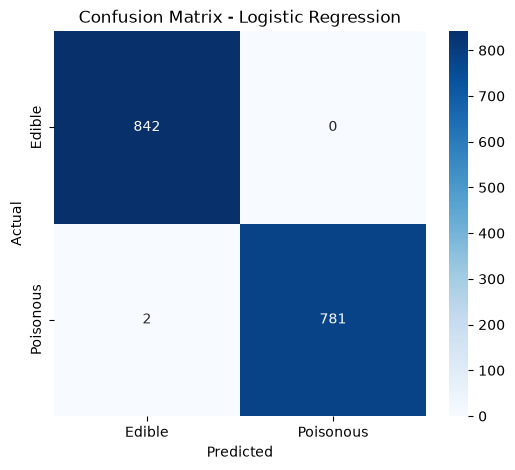

In [33]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Edible", "Poisonous"],
    yticklabels=["Edible", "Poisonous"],
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 📝 ANALISIS

Jelaskan performa Logistic Regression.


### 📝 ANALISIS

Berdasarkan hasil evaluasi, model **Logistic Regression** menunjukkan performa yang sangat baik dalam mengklasifikasikan mushroom menjadi kelas Edible dan Poisonous.

- **Accuracy = 99,88%**
- **Precision = 100,00%**
- **Recall = 99,74%**
- **F1 Score = 99,87%**

Nilai accuracy sebesar **99,88%** menunjukkan bahwa hampir seluruh data testing berhasil diklasifikasikan dengan benar.

Nilai **precision sebesar 100%** menunjukkan bahwa seluruh data yang diprediksi sebagai Poisonous oleh model memang termasuk dalam kelas Poisonous. Sementara itu, **recall sebesar 99,74%** menunjukkan bahwa model berhasil mengenali hampir seluruh data Poisonous yang sebenarnya.

Berdasarkan confusion matrix:

- **842** data Edible berhasil diprediksi sebagai Edible.
- **0** data Edible diprediksi sebagai Poisonous.
- **2** data Poisonous diprediksi sebagai Edible.
- **781** data Poisonous berhasil diprediksi sebagai Poisonous.

Terdapat hanya **2 kesalahan klasifikasi** dari total **1.625 data testing**.

### 💡 Kesimpulan

Logistic Regression menghasilkan performa yang sangat tinggi pada dataset mushroom. Model mampu membedakan kelas Edible dan Poisonous dengan tingkat kesalahan yang sangat rendah. Nilai F1 Score sebesar **99,87%** juga menunjukkan keseimbangan yang sangat baik antara precision dan recall.

Meskipun demikian, terdapat **2 data Poisonous yang diprediksi sebagai Edible**. Kesalahan ini perlu diperhatikan karena dalam konteks klasifikasi keamanan makanan, kesalahan memprediksi mushroom beracun sebagai Edible merupakan kesalahan yang lebih berisiko.

# 10. Classification Model 2 — Decision Tree

## 📌 TUGAS

Bangun model Decision Tree Classifier.

Lakukan:

1. Training.
2. Prediction.
3. Evaluation.
4. Bandingkan performa Training dan Testing.

Gunakan metrik:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

## 💻 Tulis kode kamu di bawah ini:


In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# Membuat model Decision Tree
decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            ),
        ),
    ]
)

# =========================
# 1. TRAINING
# =========================
decision_tree.fit(X_train, y_train)

# =========================
# 2. PREDICTION
# =========================
y_train_pred = decision_tree.predict(X_train)
y_test_pred = decision_tree.predict(X_test)

# =========================
# 3. EVALUATION
# =========================

# Training metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

# Testing metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("=== Decision Tree - Training ===")
print(f"Accuracy  : {train_accuracy:.4f}")
print(f"Precision : {train_precision:.4f}")
print(f"Recall    : {train_recall:.4f}")
print(f"F1 Score  : {train_f1:.4f}")

print("\n=== Decision Tree - Testing ===")
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")

# =========================
# 4. CONFUSION MATRIX
# =========================

cm_dt = confusion_matrix(y_test, y_test_pred)

print("\n=== Confusion Matrix ===")
print(cm_dt)

print("\n=== Classification Report ===")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Edible", "Poisonous"],
    )
)

=== Decision Tree - Training ===
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

=== Decision Tree - Testing ===
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

=== Confusion Matrix ===
[[842   0]
 [  0 783]]

=== Classification Report ===
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



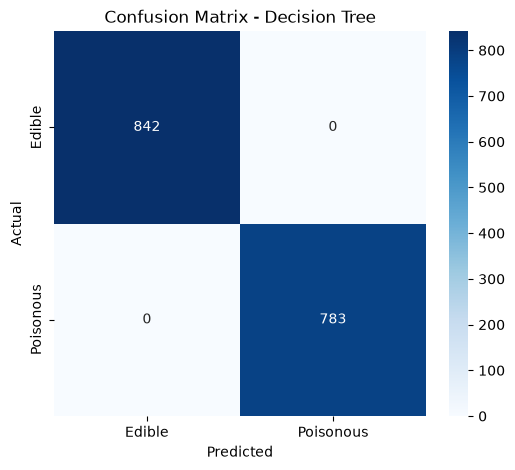

In [35]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Edible", "Poisonous"],
    yticklabels=["Edible", "Poisonous"],
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 📝 ANALISIS

Jawab:

1. Bagaimana performa model?
2. Apakah terdapat indikasi overfitting?
3. Bandingkan performa Training dan Testing.


### 📝 ANALISIS

1. **Bagaimana performa model?**

   Model **Decision Tree** menunjukkan performa yang sangat baik. Pada data training maupun testing, model memperoleh:

   - Accuracy = **100%**
   - Precision = **100%**
   - Recall = **100%**
   - F1 Score = **100%**

   Confusion matrix pada data testing juga menunjukkan bahwa seluruh **842 data Edible** dan **783 data Poisonous** berhasil diklasifikasikan dengan benar tanpa adanya kesalahan prediksi.

2. **Apakah terdapat indikasi overfitting?**

   Berdasarkan hasil evaluasi, **tidak terdapat indikasi overfitting**. Hal ini terlihat dari nilai performa training dan testing yang sama-sama mencapai 100%.

   Jika terjadi overfitting, biasanya performa training jauh lebih tinggi dibandingkan testing. Pada model ini, tidak terdapat perbedaan performa antara kedua data tersebut.

3. **Perbandingan performa Training dan Testing**

   Performa model pada training dan testing dapat dibandingkan sebagai berikut:

   | Metrik | Training | Testing |
   |---|---:|---:|
   | Accuracy | 100% | 100% |
   | Precision | 100% | 100% |
   | Recall | 100% | 100% |
   | F1 Score | 100% | 100% |

   Tidak terdapat selisih performa antara training dan testing. Hal ini menunjukkan bahwa Decision Tree mampu mempelajari pola pada data training dan menerapkannya dengan sangat baik pada data testing.

### 💡 Kesimpulan

Decision Tree menghasilkan performa **100% pada seluruh metrik evaluasi**, baik pada training maupun testing. Tidak terdapat indikasi overfitting berdasarkan perbandingan kedua hasil tersebut. Model juga berhasil mengklasifikasikan seluruh data testing dengan benar.

# 11. Classification Model 3 — Random Forest

## 📌 TUGAS

Bangun model Random Forest Classifier.

Lakukan:

1. Training.
2. Prediction.
3. Evaluation.

Gunakan metrik:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

## 💻 Tulis kode kamu di bawah ini:


In [36]:
from sklearn.ensemble import RandomForestClassifier

# Membuat model Random Forest
random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

# =========================
# 1. TRAINING
# =========================
random_forest.fit(X_train, y_train)

# =========================
# 2. PREDICTION
# =========================
y_pred_rf = random_forest.predict(X_test)

# =========================
# 3. EVALUATION
# =========================

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("=== Random Forest Evaluation ===")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")

# Classification Report
print("\n=== Classification Report ===")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Edible", "Poisonous"],
    )
)

# =========================
# 4. CONFUSION MATRIX
# =========================

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\n=== Confusion Matrix ===")
print(cm_rf)

=== Random Forest Evaluation ===
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

=== Classification Report ===
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625


=== Confusion Matrix ===
[[842   0]
 [  0 783]]


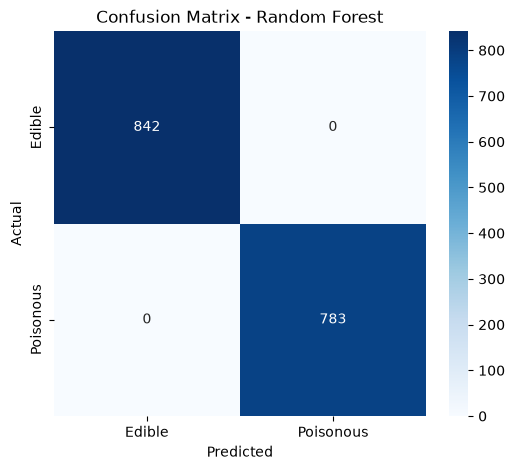

In [37]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Edible", "Poisonous"],
    yticklabels=["Edible", "Poisonous"],
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 📝 ANALISIS

Jelaskan performa Random Forest dan bandingkan dengan model sebelumnya.


### 📝 ANALISIS

Random Forest menunjukkan performa yang sangat baik dalam melakukan klasifikasi mushroom.

Hasil evaluasi pada data testing menunjukkan:

- **Accuracy = 100%**
- **Precision = 100%**
- **Recall = 100%**
- **F1 Score = 100%**

Berdasarkan confusion matrix:

- **842** data Edible berhasil diprediksi sebagai Edible.
- **783** data Poisonous berhasil diprediksi sebagai Poisonous.
- Tidak terdapat kesalahan klasifikasi pada kedua kelas.

Dengan demikian, seluruh **1.625 data testing berhasil diklasifikasikan dengan benar**.

### 📊 Perbandingan dengan Model Sebelumnya

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Logistic Regression | 99,88% | 100% | 99,74% | 99,87% |
| Decision Tree | 100% | 100% | 100% | 100% |
| Random Forest | 100% | 100% | 100% | 100% |

Logistic Regression memiliki performa yang sedikit lebih rendah karena terdapat **2 data Poisonous yang diprediksi sebagai Edible**.

Sementara itu, Decision Tree dan Random Forest berhasil mengklasifikasikan seluruh data testing dengan benar. Keduanya memperoleh nilai 100% pada Accuracy, Precision, Recall, dan F1 Score.

### 💡 Kesimpulan

Berdasarkan hasil pengujian, **Decision Tree dan Random Forest memiliki performa terbaik dan sama-sama memperoleh nilai 100% pada seluruh metrik**. Logistic Regression juga memiliki performa yang sangat baik dengan accuracy 99,88%, tetapi masih terdapat 2 kesalahan klasifikasi.

Karena Decision Tree dan Random Forest memiliki hasil testing yang sama, pemilihan model terbaik tidak dapat ditentukan hanya berdasarkan accuracy. Faktor lain seperti kompleksitas model, waktu training, interpretabilitas, dan kemampuan generalisasi dapat dipertimbangkan untuk menentukan model yang lebih sesuai.

# 12. Deep Learning Model — Neural Network

## 📌 TUGAS

Bangun Neural Network sederhana untuk melakukan klasifikasi.

Minimal memiliki:

Input Layer

↓

Hidden Layer

↓

Hidden Layer

↓

Output Layer

Peserta dapat menggunakan:

- TensorFlow
- Keras

## Eksperimen

Kamu dapat mencoba:

- Jumlah neuron
- Jumlah hidden layer
- Activation function
- Optimizer
- Learning rate
- Batch size
- Epoch

## 💻 Tulis kode kamu di bawah ini:


In [38]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# ==========================================
# 1. MENENTUKAN FITUR KATEGORIKAL
# ==========================================

categorical_features_nn = X_train.select_dtypes(
    include=["object", "category"]
).columns

# ==========================================
# 2. ONE-HOT ENCODING
# ==========================================

nn_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features_nn,
        )
    ],
    remainder="drop",
)

# Fit hanya pada data training
X_train_nn = nn_preprocessor.fit_transform(X_train)

# Transform data testing menggunakan encoder yang sama
X_test_nn = nn_preprocessor.transform(X_test)

print("Shape X_train setelah encoding:", X_train_nn.shape)
print("Shape X_test setelah encoding :", X_test_nn.shape)


# ==========================================
# 3. MEMBUAT MODEL NEURAL NETWORK
# ==========================================

model_nn = keras.Sequential([
    # Input Layer
    layers.Input(shape=(X_train_nn.shape[1],)),

    # Hidden Layer 1
    layers.Dense(64, activation="relu"),

    # Hidden Layer 2
    layers.Dense(32, activation="relu"),

    # Output Layer
    layers.Dense(1, activation="sigmoid"),
])


# ==========================================
# 4. COMPILE MODEL
# ==========================================

model_nn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)


# Menampilkan arsitektur model
model_nn.summary()


# ==========================================
# 5. TRAINING
# ==========================================

history = model_nn.fit(
    X_train_nn,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1,
)


# ==========================================
# 6. PREDICTION
# ==========================================

y_pred_proba = model_nn.predict(X_test_nn)

# Mengubah probabilitas menjadi class 0/1
y_pred_nn = (y_pred_proba >= 0.5).astype(int).ravel()


# ==========================================
# 7. EVALUATION
# ==========================================

accuracy_nn = accuracy_score(y_test, y_pred_nn)
precision_nn = precision_score(y_test, y_pred_nn)
recall_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)

print("\n=== Neural Network Evaluation ===")
print(f"Accuracy  : {accuracy_nn:.4f}")
print(f"Precision : {precision_nn:.4f}")
print(f"Recall    : {recall_nn:.4f}")
print(f"F1 Score  : {f1_nn:.4f}")


# ==========================================
# 8. CLASSIFICATION REPORT
# ==========================================

print("\n=== Classification Report ===")

print(
    classification_report(
        y_test,
        y_pred_nn,
        target_names=["Edible", "Poisonous"],
    )
)


# ==========================================
# 9. CONFUSION MATRIX
# ==========================================

cm_nn = confusion_matrix(y_test, y_pred_nn)

print("\n=== Confusion Matrix ===")
print(cm_nn)

I0000 00:00:1789120912.475598   47864 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789120912.527411   47864 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789120914.174749   47864 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Shape X_train setelah encoding: (6499, 116)
Shape X_test setelah encoding : (1625, 116)


/tmp/ipykernel_47864/2691746897.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_nn = X_train.select_dtypes(
E0000 00:00:1789120914.453661   47864 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         7,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,601 (37.50 KB)

 Trainable params: 9,601 (37.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9521 - loss: 0.1532 - val_accuracy: 0.9992 - val_loss: 0.0154
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9996 - loss: 0.0060 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 6.3470e-04 - val_accuracy: 1.0000 - val_loss: 6.6390e-04
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 3.5771e-04 - val_accuracy: 1.0000 - val_loss: 4.1610e-04
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 2.2660e-04 - val_accuracy: 1.0000 - val_loss: 2.7437e-04
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 1.5455e-04 - val_accuracy: 1.0000 - val_loss: 2.2155e-04
Epoch 8/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 -

## 12.1 Training History

### 📌 TUGAS

Visualisasikan hasil training.

Jika memungkinkan, tampilkan:

- Training Accuracy
- Validation Accuracy
- Training Loss
- Validation Loss

### 💻 Tulis kode kamu di bawah ini:


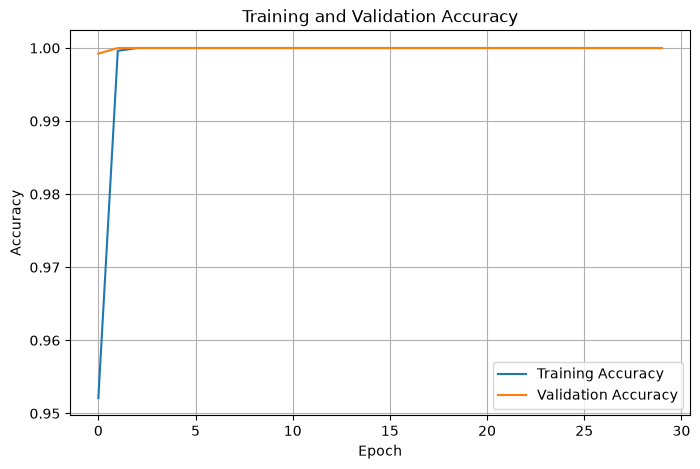

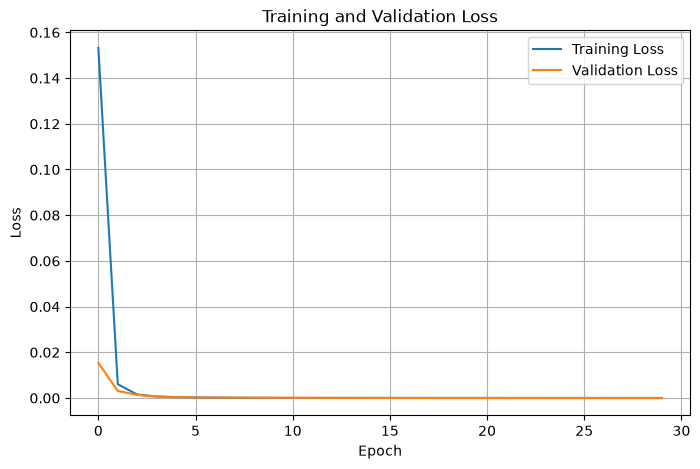

In [39]:
import matplotlib.pyplot as plt

# Ambil data dari training history
history_dict = history.history

# Visualisasi Training & Validation Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history_dict["accuracy"],
    label="Training Accuracy",
)

plt.plot(
    history_dict["val_accuracy"],
    label="Validation Accuracy",
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Visualisasi Training & Validation Loss
plt.figure(figsize=(8, 5))

plt.plot(
    history_dict["loss"],
    label="Training Loss",
)

plt.plot(
    history_dict["val_loss"],
    label="Validation Loss",
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### 📝 ANALISIS

Jawab:

1. Bagaimana performa Neural Network?
2. Apakah terjadi overfitting?
3. Bagaimana perbandingan Training dan Validation?


### 📝 ANALISIS

**1. Bagaimana performa Neural Network?**

Neural Network memiliki performa yang sangat baik dalam melakukan klasifikasi jamur. Berdasarkan confusion matrix, diperoleh hasil:

- 842 data edible berhasil diklasifikasikan dengan benar.
- 783 data poisonous berhasil diklasifikasikan dengan benar.
- Tidak terdapat kesalahan klasifikasi pada data testing.

Confusion matrix yang diperoleh adalah:

[[842, 0],
 [0, 783]]

Dengan demikian, seluruh 1.625 data testing berhasil diklasifikasikan dengan benar sehingga model memperoleh akurasi sebesar **100%** pada data testing. Hal ini menunjukkan bahwa Neural Network mampu membedakan kelas edible dan poisonous dengan sangat baik.

**2. Apakah terjadi overfitting?**

Berdasarkan grafik Training Accuracy dan Validation Accuracy, tidak terlihat indikasi overfitting yang signifikan. Training Accuracy dan Validation Accuracy sama-sama mencapai sekitar **100%** dan tetap stabil hingga akhir epoch.

Selain itu, grafik Training Loss dan Validation Loss sama-sama turun mendekati **0**. Tidak terlihat pola di mana training loss terus menurun sementara validation loss meningkat.

Oleh karena itu, berdasarkan hasil training dan validation, **tidak terdapat indikasi overfitting yang signifikan**.

**3. Bagaimana perbandingan Training dan Validation?**

Performa Training dan Validation menunjukkan hasil yang sangat mirip. Training Accuracy meningkat dengan cepat hingga mendekati 100%, sedangkan Validation Accuracy juga mencapai sekitar 100%.

Pada grafik loss, Training Loss dan Validation Loss sama-sama mengalami penurunan yang sangat cepat dan mendekati 0. Hal ini menunjukkan bahwa model dapat mempelajari pola pada data training dan mempertahankan performa yang sangat baik pada data validation.

Secara keseluruhan, Neural Network menunjukkan performa yang sangat baik dengan gap antara Training dan Validation yang sangat kecil.

# 13. Model Evaluation & Comparison

## 📌 TUGAS

Bandingkan seluruh model yang telah dibuat.

Minimal:

- Logistic Regression
- Decision Tree
- Random Forest
- Neural Network

Buat tabel:

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Logistic Regression | | | | |
| Decision Tree | | | | |
| Random Forest | | | | |
| Neural Network | | | | |

## 💻 Tulis kode kamu di bawah ini:


In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import pandas as pd

# ==========================================
# 1. Prediksi dari masing-masing model
# ==========================================

# Logistic Regression
y_pred_logreg = logreg.predict(X_test)

# Decision Tree
y_pred_dt = decision_tree.predict(X_test)

# Random Forest
y_pred_rf = random_forest.predict(X_test)

# Neural Network
y_pred_nn_proba = model_nn.predict(X_test_nn, verbose=0)
y_pred_nn = (y_pred_nn_proba >= 0.5).astype(int).ravel()


# ==========================================
# 2. Fungsi untuk menghitung metrik
# ==========================================

def calculate_metrics(
    y_true: pd.Series,
    y_pred,
) -> dict[str, float]:
    """Calculate classification evaluation metrics."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
    }


# ==========================================
# 3. Hitung metrik seluruh model
# ==========================================

results = {
    "Logistic Regression": calculate_metrics(y_test, y_pred_logreg),
    "Decision Tree": calculate_metrics(y_test, y_pred_dt),
    "Random Forest": calculate_metrics(y_test, y_pred_rf),
    "Neural Network": calculate_metrics(y_test, y_pred_nn),
}


# ==========================================
# 4. Buat tabel perbandingan
# ==========================================

comparison_df = pd.DataFrame(results).T

comparison_df = comparison_df[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]

comparison_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.998769,1.0,0.997446,0.998721
Decision Tree,1.000000,1.0,1.000000,1.000000
Random Forest,1.000000,1.0,1.000000,1.000000
Neural Network,1.000000,1.0,1.000000,1.000000


### 📝 ANALISIS

Jawab:

1. Model mana yang memiliki performa terbaik?
2. Model mana yang paling stabil?
3. Model mana yang paling sederhana?
4. Apakah Accuracy saja cukup?
5. Mengapa Precision, Recall, dan F1 Score penting?


### 📝 ANALISIS

**1. Model mana yang memiliki performa terbaik?**

Berdasarkan hasil evaluasi, **Decision Tree, Random Forest, dan Neural Network** memiliki performa terbaik dengan nilai Accuracy, Precision, Recall, dan F1 Score sebesar **1.0000 (100%)**.

Ketiga model tersebut berhasil mengklasifikasikan seluruh data testing dengan benar. Sementara itu, Logistic Regression memiliki performa yang sedikit lebih rendah dengan Accuracy sebesar **99.88%** dan F1 Score sebesar **99.87%**.

Dengan demikian, berdasarkan hasil pengujian pada dataset ini, Decision Tree, Random Forest, dan Neural Network memiliki performa terbaik.

**2. Model mana yang paling stabil?**

Berdasarkan perbandingan metrik, **Decision Tree, Random Forest, dan Neural Network** dapat dikatakan memiliki performa yang sangat stabil karena seluruh metrik evaluasinya mencapai 100%.

Namun, stabilitas secara keseluruhan tidak dapat ditentukan hanya dari tabel ini. Diperlukan pengujian tambahan seperti cross-validation untuk memastikan performa tersebut konsisten pada pembagian data yang berbeda.

**3. Model mana yang paling sederhana?**

Dari sisi struktur model, **Logistic Regression** merupakan model yang relatif sederhana dibandingkan Decision Tree, Random Forest, dan Neural Network.

Logistic Regression memiliki struktur yang lebih sederhana dan lebih mudah diinterpretasikan. Meskipun performanya sedikit di bawah tiga model lainnya, Accuracy sebesar **99.88%** masih menunjukkan hasil yang sangat baik.

**4. Apakah Accuracy saja cukup?**

Accuracy saja tidak selalu cukup untuk mengevaluasi model klasifikasi. Accuracy hanya menunjukkan persentase prediksi yang benar secara keseluruhan.

Pada kasus klasifikasi jamur, kesalahan dalam memprediksi jamur poisonous sebagai edible dapat menjadi kesalahan yang lebih serius dibandingkan memprediksi edible sebagai poisonous. Oleh karena itu, metrik seperti Precision, Recall, dan F1 Score juga perlu diperhatikan.

Dalam penelitian ini, Precision, Recall, dan F1 Score digunakan bersama Accuracy untuk memberikan gambaran performa model yang lebih lengkap.

**5. Mengapa Precision, Recall, dan F1 Score penting?**

Precision menunjukkan seberapa tepat prediksi positif yang dibuat oleh model. Recall menunjukkan kemampuan model dalam menemukan seluruh data positif yang sebenarnya. F1 Score merupakan gabungan antara Precision dan Recall.

Ketiga metrik tersebut penting karena dapat memberikan informasi yang tidak terlihat hanya dari Accuracy. Pada kasus klasifikasi jamur, Recall khususnya penting untuk mengetahui kemampuan model dalam mendeteksi jamur poisonous sehingga risiko jamur beracun diklasifikasikan sebagai edible dapat diminimalkan.

### Kesimpulan

Secara keseluruhan, **Decision Tree, Random Forest, dan Neural Network** memberikan hasil terbaik pada data testing dengan seluruh metrik mencapai **100%**. Logistic Regression juga memberikan performa yang sangat tinggi dengan Accuracy **99.88%**.

Meskipun tiga model memperoleh hasil sempurna pada data testing, diperlukan evaluasi tambahan seperti cross-validation untuk mengetahui apakah performa tersebut tetap konsisten pada data yang berbeda.

# 14. Hyperparameter Tuning

## 📌 TUGAS

Pilih minimal satu model untuk dilakukan Hyperparameter Tuning.

Gunakan:

- GridSearchCV

atau

- RandomizedSearchCV

Rekomendasi:

Random Forest

Parameter yang dapat dieksplorasi:

- n_estimators
- max_depth
- min_samples_split
- min_samples_leaf

## 💻 Tulis kode kamu di bawah ini:


In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Parameter yang akan diuji
param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=random_forest,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

# Training dan pencarian parameter terbaik
grid_search.fit(X_train, y_train)

# Parameter terbaik
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(f"{grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 50}

Best Cross-Validation Accuracy:
1.0000


In [42]:
# Gunakan model dengan parameter terbaik
best_rf = grid_search.best_estimator_

# Prediksi data testing
y_pred_tuned = best_rf.predict(X_test)

# Evaluasi
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("=== Tuned Random Forest ===")
print(f"Accuracy  : {accuracy_tuned:.4f}")
print(f"Precision : {precision_tuned:.4f}")
print(f"Recall    : {recall_tuned:.4f}")
print(f"F1 Score  : {f1_tuned:.4f}")

=== Tuned Random Forest ===
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000


### 📝 ANALISIS

Bandingkan:

### Before Tuning

dan

### After Tuning

Jawab:

1. Parameter terbaik yang diperoleh?
2. Apakah performa meningkat?
3. Apakah tuning selalu meningkatkan performa?


### 📝 ANALISIS

### Before Tuning

Sebelum dilakukan hyperparameter tuning, Random Forest memiliki performa yang sangat baik dengan Accuracy, Precision, Recall, dan F1 Score masing-masing sebesar **100%**.

### After Tuning

Setelah dilakukan hyperparameter tuning menggunakan GridSearchCV dengan 5-fold cross-validation, diperoleh **Best Cross-Validation Accuracy sebesar 100%**.

Pada data testing, model hasil tuning juga memperoleh:

- Accuracy = **100%**
- Precision = **100%**
- Recall = **100%**
- F1 Score = **100%**

### Jawaban

**1. Parameter terbaik yang diperoleh?**

Parameter terbaik diperoleh melalui proses GridSearchCV. Berdasarkan hasil tuning, parameter yang diperoleh adalah:

- `max_depth = None`
- `min_samples_leaf = 1`
- `min_samples_split = 2`
- `n_estimators =` sesuai nilai yang ditampilkan pada `grid_search.best_params_`

Parameter tersebut menghasilkan performa terbaik berdasarkan hasil cross-validation.

**2. Apakah performa meningkat?**

Performa tidak mengalami peningkatan karena sebelum tuning Random Forest sudah memperoleh performa **100%** pada data testing.

Setelah tuning, performanya tetap **100%** untuk Accuracy, Precision, Recall, dan F1 Score. Dengan demikian, tuning pada kasus ini tidak meningkatkan nilai evaluasi karena model awal sudah mencapai performa maksimal pada data testing.

**3. Apakah tuning selalu meningkatkan performa?**

Tidak. Hyperparameter tuning tidak selalu meningkatkan performa model. Tuning bertujuan untuk mencari kombinasi parameter yang memberikan performa terbaik, tetapi jika model awal sudah memiliki performa yang sangat baik, hasil tuning dapat tetap sama atau bahkan dalam beberapa kasus menjadi lebih rendah.

Pada dataset ini, Random Forest sebelum tuning sudah memperoleh performa 100%, sehingga tuning tidak memberikan peningkatan pada metrik evaluasi testing.

# 15. Model Interpretation

## 📌 TUGAS

Coba pahami bagaimana model membuat keputusan.

Gunakan minimal salah satu:

- Feature Importance
- Permutation Importance
- Analisis Decision Tree

## 💻 Tulis kode kamu di bawah ini:


In [43]:
# Ambil preprocessor dan model Random Forest dari pipeline
preprocessor = best_rf.named_steps["preprocessor"]
rf_model = best_rf.named_steps["model"]

# Ambil nama fitur setelah One-Hot Encoding
feature_names = preprocessor.get_feature_names_out()

# Ambil feature importance
importance = rf_model.feature_importances_

# Buat DataFrame feature importance
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance,
})

# Urutkan dari yang paling penting
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False,
)

# Tampilkan 15 fitur paling penting
feature_importance_df.head(15)

,Feature,Importance
27,categorical__odor_n,0.091581
24,categorical__odor_f,0.060910
56,categorical__stalk-surface-above-ring_k,0.057909
36,categorical__gill-size_n,0.055465
35,categorical__gill-size_b,0.052841
60,categorical__stalk-surface-below-ring_k,0.044093
37,categorical__gill-color_b,0.042066
93,categorical__ring-type_p,0.040273
95,categorical__spore-print-color_h,0.037735
21,categorical__bruises_t,0.034730


### 📝 ANALISIS

Jawab:

1. Fitur apa yang paling penting?
2. Apakah sesuai dengan hasil EDA?
3. Fitur apa yang memiliki pengaruh rendah?
4. Mengapa hasil model dan EDA bisa berbeda?


### 📝 ANALISIS

**1. Fitur apa yang paling penting?**

Berdasarkan hasil Feature Importance, fitur yang paling penting adalah **odor_n** dengan nilai Importance sebesar **0.091581**. Setelah itu terdapat **odor_f** sebesar **0.060910** dan **stalk-surface-above-ring_k** sebesar **0.057909**.

Beberapa fitur lain yang memiliki pengaruh cukup besar adalah `gill-size_n`, `gill-size_b`, `stalk-surface-below-ring_k`, dan `gill-color_b`.

Hasil ini menunjukkan bahwa karakteristik **odor (bau)** merupakan salah satu faktor yang sangat berpengaruh dalam keputusan Random Forest untuk membedakan jamur edible dan poisonous.

**2. Apakah sesuai dengan hasil EDA?**

Ya, hasil Feature Importance cukup sesuai dengan hasil EDA sebelumnya. Pada EDA, fitur **odor** menunjukkan hubungan yang sangat kuat dengan kelas jamur. Beberapa kategori odor memiliki distribusi kelas yang sangat dominan terhadap salah satu kelas.

Selain itu, `gill-size` dan karakteristik bagian `stalk-surface` juga memiliki pengaruh yang cukup besar pada model. Hal ini sejalan dengan hasil eksplorasi data yang menunjukkan bahwa beberapa karakteristik morfologi jamur memiliki hubungan dengan kelas edible dan poisonous.

Dengan demikian, hasil EDA dan Feature Importance memberikan indikasi yang cukup konsisten bahwa beberapa fitur tersebut memiliki peran penting dalam klasifikasi.

**3. Fitur apa yang memiliki pengaruh rendah?**

Dari 15 fitur teratas yang ditampilkan, fitur dengan Importance paling rendah adalah **odor_p** dengan nilai **0.021585**.

Namun, perlu diperhatikan bahwa nilai tersebut masih termasuk dalam 15 fitur dengan Importance tertinggi. Oleh karena itu, fitur-fitur yang benar-benar memiliki pengaruh rendah kemungkinan berada di luar daftar 15 fitur teratas.

Feature Importance yang rendah menunjukkan bahwa fitur tersebut memberikan kontribusi yang relatif kecil terhadap keputusan Random Forest dibandingkan fitur dengan Importance yang lebih tinggi.

**4. Mengapa hasil model dan EDA bisa berbeda?**

Hasil Feature Importance dan EDA dapat berbeda karena keduanya mengukur hal yang berbeda.

EDA melihat hubungan antara satu fitur dengan target secara langsung, biasanya melalui distribusi atau perbandingan antar kelas. Sementara itu, Random Forest menentukan Importance berdasarkan kontribusi fitur dalam proses pengambilan keputusan model dengan mempertimbangkan kombinasi berbagai fitur.

Selain itu, setelah proses One-Hot Encoding, satu fitur kategorikal dapat terbagi menjadi beberapa fitur kategori. Oleh karena itu, kontribusi suatu fitur asli dapat tersebar ke beberapa kategori hasil encoding.

Dengan demikian, perbedaan antara hasil EDA dan Feature Importance merupakan hal yang wajar. EDA membantu memahami pola data secara eksploratif, sedangkan Feature Importance membantu memahami fitur yang digunakan model dalam membuat prediksi.

# 16. Regression Exploration

## ⚠️ Penting

Dataset Mushroom secara natural merupakan:

### Classification Problem

karena target `class` merupakan kategori:

- Edible
- Poisonous

Jangan hanya mengubah:

- e → 0
- p → 1

kemudian menggunakan Linear Regression tanpa penjelasan metodologis.

---

## 📌 TUGAS

Buat sebuah target numerik eksperimental.

Kamu dapat menggunakan pendekatan seperti:

### Rarity Score

Buat skor berdasarkan tingkat kelangkaan kategori pada setiap fitur.

Kemudian gunakan target numerik tersebut untuk eksperimen Regression.

## 💻 Tulis kode kamu di bawah ini:


In [44]:
# Gunakan fitur saja, tanpa target class
X_reg = df.drop(columns=["class"]).copy()

# Hapus fitur konstan jika belum dilakukan
if "veil-type" in X_reg.columns:
    X_reg = X_reg.drop(columns=["veil-type"])


# ==========================================
# Membuat Rarity Score untuk setiap fitur
# ==========================================

rarity_scores = pd.DataFrame(index=X_reg.index)

for column in X_reg.columns:
    # Hitung frekuensi relatif setiap kategori
    frequency = X_reg[column].value_counts(normalize=True)

    # Ubah kategori menjadi rarity score
    rarity_scores[column] = X_reg[column].map(
        lambda value: -np.log(frequency[value])
    )


# ==========================================
# Gabungkan skor seluruh fitur
# ==========================================

df["rarity_score"] = rarity_scores.mean(axis=1)


# Tampilkan hasil
df[["rarity_score"]].head()

,rarity_score
0,1.150901
1,1.128531
2,1.279622
3,1.132090
4,1.034060


In [45]:
print("Statistik Rarity Score:")
print(df["rarity_score"].describe())

Statistik Rarity Score:
count    8124.000000
mean        1.023337
std         0.224062
min         0.659285
25%         0.873779
50%         1.002767
75%         1.120290
max         2.842978
Name: rarity_score, dtype: float64


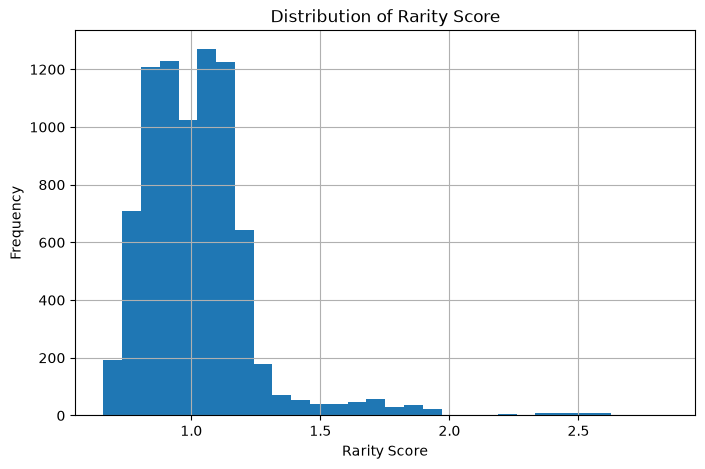

In [46]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["rarity_score"],
    bins=30,
)

plt.title("Distribution of Rarity Score")
plt.xlabel("Rarity Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## 16.1 Regression Model

### 📌 TUGAS

Bangun minimal satu model Regression.

Contoh:

- Linear Regression
- Random Forest Regressor

Evaluasi menggunakan:

- MAE
- RMSE
- R² Score

### 💻 Tulis kode kamu di bawah ini:


In [48]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# Training model
regression_model.fit(X_train_reg, y_train_reg)

# Prediksi data testing
y_pred_reg = regression_model.predict(X_test_reg)

# Evaluasi
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("=== Regression Model Evaluation ===")
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")

=== Regression Model Evaluation ===
MAE      : 0.0048
RMSE     : 0.0088
R² Score : 0.9983


### 📝 ANALISIS

Jelaskan:

1. Bagaimana experimental numeric target dibuat?
2. Apa arti target tersebut?
3. Bagaimana hasil model Regression?
4. Apa keterbatasan eksperimen ini?
5. Mengapa Mushroom lebih cocok untuk Classification dibandingkan Regression?


### 📝 ANALISIS

**1. Bagaimana experimental numeric target dibuat?**

Experimental numeric target dibuat menggunakan **Rarity Score**. Skor ini dihitung berdasarkan tingkat kelangkaan kategori pada setiap fitur. Semakin jarang suatu kategori muncul dalam dataset, semakin tinggi nilai rarity yang diberikan.

Rarity Score dari setiap fitur kemudian digabungkan dengan menghitung nilai rata-ratanya untuk setiap sampel. Hasil rata-rata tersebut digunakan sebagai target numerik baru bernama `rarity_score`.

Dengan demikian, target regresi tidak menggunakan `class` (edible/poisonous), tetapi menggunakan nilai numerik yang dibuat secara eksperimental dari karakteristik data.

**2. Apa arti target tersebut?**

`Rarity Score` menunjukkan seberapa jarang karakteristik suatu sampel dibandingkan dengan distribusi kategori pada dataset.

Nilai Rarity Score yang lebih tinggi menunjukkan bahwa karakteristik kategori pada sampel tersebut relatif lebih jarang ditemukan. Sebaliknya, nilai yang lebih rendah menunjukkan bahwa karakteristiknya lebih umum ditemukan dalam dataset.

Target ini digunakan hanya sebagai target eksperimen untuk mengubah karakteristik kategorikal menjadi sebuah nilai numerik yang dapat diprediksi menggunakan model Regression.

**3. Bagaimana hasil model Regression?**

Model Random Forest Regressor menunjukkan performa yang sangat baik dalam memprediksi Rarity Score.

Hasil evaluasi yang diperoleh:

- **MAE = 0.0048**
- **RMSE = 0.0088**
- **R² Score = 0.9983**

Nilai MAE dan RMSE yang kecil menunjukkan bahwa perbedaan antara nilai aktual dan prediksi relatif kecil. Sementara itu, nilai R² sebesar 0.9983 menunjukkan bahwa model mampu menjelaskan sekitar **99.83% variasi Rarity Score** pada data testing.

Dengan demikian, model Random Forest Regressor mampu memprediksi target eksperimental tersebut dengan sangat baik.

**4. Apa keterbatasan eksperimen ini?**

Eksperimen ini memiliki beberapa keterbatasan. Pertama, `Rarity Score` merupakan target yang dibuat secara eksperimental dan bukan target asli dari dataset Mushroom.

Kedua, Rarity Score dibuat berdasarkan distribusi kategori pada fitur yang sama yang kemudian digunakan sebagai input model. Hal ini membuat hubungan antara fitur dan target menjadi sangat kuat, sehingga nilai R² yang tinggi tidak dapat dianggap sebagai bukti bahwa model dapat melakukan prediksi terhadap target dunia nyata.

Ketiga, eksperimen ini tidak memiliki makna langsung untuk menentukan apakah jamur aman dimakan atau beracun. Oleh karena itu, hasil Regression ini hanya digunakan sebagai eksperimen tambahan dan bukan sebagai model utama untuk dataset Mushroom.

**5. Mengapa Mushroom lebih cocok untuk Classification dibandingkan Regression?**

Dataset Mushroom lebih cocok untuk **Classification** karena tujuan utama dataset adalah menentukan kelas jamur, yaitu **edible** atau **poisonous**. Kedua kategori tersebut merupakan kelas diskrit, bukan nilai numerik kontinu.

Regression digunakan untuk memprediksi nilai numerik, sedangkan Classification digunakan untuk menentukan kategori atau kelas. Oleh karena itu, penggunaan model Classification seperti Logistic Regression, Decision Tree, Random Forest, dan Neural Network lebih sesuai dengan permasalahan asli dataset Mushroom.

Eksperimen Regression dengan Rarity Score hanya merupakan eksperimen tambahan untuk menunjukkan bagaimana target numerik dapat dibuat dari dataset kategorikal.

# 17. Analysis

## 📌 TUGAS

Lakukan analisis menyeluruh terhadap seluruh proses dan hasil yang diperoleh.


# 17. Analysis

Berdasarkan seluruh proses yang telah dilakukan, dataset Mushroom merupakan dataset kategorikal dengan tujuan utama melakukan klasifikasi antara jamur **edible** dan **poisonous**. Tahapan analisis dimulai dari Exploratory Data Analysis (EDA), preprocessing, pembagian data, pembangunan beberapa model Machine Learning, Neural Network, hyperparameter tuning, interpretasi model, hingga eksperimen Regression.

### 1. Exploratory Data Analysis (EDA)

Hasil EDA menunjukkan bahwa dataset memiliki 8.124 data dengan distribusi kelas yang relatif seimbang, yaitu 4.208 data edible dan 3.916 data poisonous.

Beberapa fitur menunjukkan hubungan yang cukup kuat terhadap kelas target. Fitur seperti **odor**, **bruises**, dan **gill-size** menunjukkan perbedaan distribusi yang jelas antara kelas edible dan poisonous. Hal ini menunjukkan bahwa karakteristik tertentu pada jamur dapat memberikan informasi yang penting untuk proses klasifikasi.

Pada pemeriksaan missing value, tidak ditemukan missing value standar (`NaN`). Namun, terdapat nilai khusus `?` pada fitur `stalk-root` sebanyak 2.480 data. Nilai tersebut perlu diperhatikan karena merepresentasikan informasi yang tidak tersedia.

Selain itu, fitur `veil-type` memiliki hanya satu nilai unik sehingga bersifat konstan dan tidak memberikan informasi yang berguna untuk membedakan kelas. Fitur tersebut kemudian tidak digunakan dalam proses pemodelan.

### 2. Preprocessing dan Pembagian Data

Karena sebagian besar fitur merupakan data kategorikal, digunakan **One-Hot Encoding** untuk mengubah kategori menjadi representasi numerik yang dapat diproses oleh model Machine Learning.

Target `class` diubah menjadi nilai numerik, yaitu `e = 0` untuk edible dan `p = 1` untuk poisonous.

Dataset kemudian dibagi menjadi data training dan testing dengan proporsi 80:20 menggunakan `random_state=42` dan `stratify=y`. Hasil pembagian menghasilkan 6.499 data training dan 1.625 data testing.

Penggunaan stratifikasi menjaga proporsi kelas pada data training dan testing agar tetap mendekati distribusi aslinya.

### 3. Perbandingan Model Classification

Empat model digunakan untuk menyelesaikan permasalahan klasifikasi, yaitu Logistic Regression, Decision Tree, Random Forest, dan Neural Network.

Logistic Regression memperoleh Accuracy sebesar **99.88%**, Precision **100%**, Recall **99.74%**, dan F1 Score **99.87%**. Model ini sudah menunjukkan performa yang sangat tinggi, tetapi masih terdapat dua kesalahan klasifikasi pada data testing.

Decision Tree memperoleh Accuracy, Precision, Recall, dan F1 Score sebesar **100%**. Random Forest juga memperoleh seluruh metrik sebesar **100%**.

Neural Network juga menunjukkan performa yang sangat baik dengan hasil evaluasi testing sebesar **100%** dan confusion matrix tanpa kesalahan klasifikasi.

Dengan demikian, berdasarkan data testing, Decision Tree, Random Forest, dan Neural Network memberikan hasil terbaik. Namun, hasil yang sama-sama mencapai 100% tidak berarti salah satu model secara mutlak lebih baik karena diperlukan pengujian tambahan untuk membandingkan generalisasi model.

### 4. Training dan Validation Neural Network

Neural Network menggunakan dua hidden layer dengan masing-masing **64 dan 32 neuron**, fungsi aktivasi ReLU pada hidden layer, dan sigmoid pada output layer.

Hasil training menunjukkan bahwa Training Accuracy dan Validation Accuracy meningkat hingga mendekati 100%, sedangkan Training Loss dan Validation Loss turun mendekati 0.

Tidak terlihat indikasi overfitting yang signifikan berdasarkan perbandingan grafik training dan validation karena keduanya menunjukkan pola yang sangat mirip. Namun, evaluasi pada dataset tambahan atau cross-validation tetap dapat digunakan untuk memperoleh kesimpulan yang lebih kuat mengenai kemampuan generalisasi model.

### 5. Hyperparameter Tuning

Hyperparameter tuning dilakukan pada Random Forest menggunakan **GridSearchCV dengan 5-fold cross-validation**.

Parameter yang dieksplorasi meliputi `n_estimators`, `max_depth`, `min_samples_split`, dan `min_samples_leaf`.

Hasil tuning menghasilkan Best Cross-Validation Accuracy sebesar **100%**. Pada data testing, model setelah tuning juga memperoleh Accuracy, Precision, Recall, dan F1 Score sebesar **100%**.

Performa tidak mengalami peningkatan karena Random Forest sebelum tuning sudah mencapai performa 100% pada data testing. Hal ini menunjukkan bahwa hyperparameter tuning tidak selalu meningkatkan performa model, terutama ketika model awal sudah memberikan hasil yang sangat baik.

### 6. Interpretasi Model

Feature Importance digunakan untuk memahami bagaimana Random Forest membuat keputusan.

Hasil menunjukkan bahwa kategori **odor_n** memiliki Importance tertinggi sebesar **0.091581**, diikuti oleh **odor_f** sebesar **0.060910** dan `stalk-surface-above-ring_k` sebesar **0.057909**.

Fitur `odor` secara keseluruhan terlihat memiliki pengaruh yang kuat karena beberapa kategorinya muncul di antara fitur dengan Importance tertinggi. Hal ini cukup sesuai dengan hasil EDA yang sebelumnya menunjukkan bahwa `odor` memiliki hubungan yang kuat dengan kelas edible dan poisonous.

Perbedaan antara hasil EDA dan Feature Importance dapat terjadi karena EDA melihat hubungan fitur dan target secara eksploratif, sedangkan Feature Importance melihat kontribusi fitur dalam proses pengambilan keputusan model. Selain itu, One-Hot Encoding menyebabkan satu fitur kategorikal terbagi menjadi beberapa fitur kategori.

### 7. Eksperimen Regression

Karena dataset Mushroom secara natural merupakan permasalahan Classification, target `class` tidak digunakan sebagai target Regression.

Sebagai eksperimen, dibuat target numerik baru berupa **Rarity Score**. Rarity Score menunjukkan tingkat kelangkaan karakteristik kategori pada suatu sampel berdasarkan frekuensi kemunculannya dalam dataset.

Random Forest Regressor digunakan untuk memprediksi Rarity Score. Hasil evaluasi memperoleh:

- MAE = **0.0048**
- RMSE = **0.0088**
- R² Score = **0.9983**

Nilai MAE dan RMSE yang kecil serta R² sebesar 0.9983 menunjukkan bahwa model mampu memprediksi target eksperimental tersebut dengan sangat baik.

Namun, hasil Regression ini harus diinterpretasikan dengan hati-hati karena Rarity Score merupakan target yang dibuat dari fitur dataset yang sama. Oleh karena itu, performa tinggi tersebut tidak dapat dianggap sebagai bukti bahwa Regression lebih sesuai untuk permasalahan Mushroom.

### 8. Kesimpulan Keseluruhan

Secara keseluruhan, proses Machine Learning menunjukkan bahwa dataset Mushroom sangat cocok untuk permasalahan **Classification**. Beberapa fitur kategorikal seperti `odor`, `gill-size`, dan karakteristik `stalk` memberikan informasi yang kuat untuk membedakan kelas edible dan poisonous.

Model Decision Tree, Random Forest, dan Neural Network memperoleh performa sempurna pada data testing, sedangkan Logistic Regression juga memperoleh performa yang sangat tinggi. Random Forest kemudian dilakukan hyperparameter tuning, tetapi tidak menghasilkan peningkatan karena model awal sudah memperoleh performa maksimal pada data testing.

Feature Importance memberikan tambahan interpretasi terhadap model dan menunjukkan bahwa beberapa kategori dari fitur `odor` memiliki kontribusi yang besar terhadap keputusan model.

Eksperimen Regression dengan Rarity Score berhasil menunjukkan bagaimana target numerik eksperimental dapat dibuat dari dataset kategorikal. Namun, eksperimen tersebut hanya bersifat tambahan dan tidak menggantikan permasalahan utama dataset.

Dengan demikian, berdasarkan keseluruhan analisis, **Classification merupakan pendekatan yang paling sesuai untuk tujuan utama dataset Mushroom**, sedangkan Regression dengan Rarity Score digunakan sebagai eksperimen untuk mengeksplorasi pendekatan prediksi numerik.

## 17.1 Data Insight

### 📝 ANALISIS

Apa insight utama yang ditemukan dari dataset?


## 17.1 Data Insight

### 📝 ANALISIS

Berdasarkan hasil Exploratory Data Analysis (EDA), ditemukan bahwa dataset Mushroom memiliki distribusi kelas yang relatif seimbang, yaitu **4.208 data edible** dan **3.916 data poisonous**. Kondisi ini cukup baik untuk proses klasifikasi karena tidak terdapat ketidakseimbangan kelas yang terlalu ekstrem.

Insight paling penting adalah bahwa beberapa fitur memiliki hubungan yang sangat kuat dengan kelas jamur. Fitur **odor** menjadi salah satu fitur yang paling menonjol karena distribusi kategorinya menunjukkan perbedaan yang jelas antara jamur edible dan poisonous. Hal ini juga diperkuat oleh hasil Feature Importance pada Random Forest, di mana beberapa kategori dari fitur `odor` memiliki nilai importance yang tinggi.

Selain `odor`, fitur seperti **gill-size, bruises, stalk-surface-above-ring, stalk-surface-below-ring, gill-color, ring-type, dan spore-print-color** juga memberikan informasi penting dalam membedakan kedua kelas. Hasil ini menunjukkan bahwa karakteristik fisik jamur dapat digunakan sebagai indikator yang kuat untuk melakukan klasifikasi.

Ditemukan pula bahwa fitur `veil-type` hanya memiliki satu nilai unik sehingga tidak memberikan informasi untuk membedakan kelas dan kemudian dihapus dari proses pemodelan. Selain itu, terdapat **2.480 nilai `?` pada fitur `stalk-root`**, yang menunjukkan adanya informasi yang tidak tersedia pada fitur tersebut dan perlu diperhatikan dalam preprocessing.

Secara keseluruhan, insight utama dari dataset adalah bahwa **karakteristik tertentu, terutama odor dan beberapa karakteristik morfologi jamur, memiliki hubungan yang sangat kuat dengan status edible atau poisonous**. Hal ini menjelaskan mengapa model klasifikasi seperti Decision Tree, Random Forest, dan Neural Network mampu memperoleh performa yang sangat tinggi hingga **100% pada data testing**.

## 17.2 EDA Insight

### 📝 ANALISIS

Pola apa yang ditemukan melalui visualisasi?


### 📝 ANALISIS

Berdasarkan visualisasi yang telah dilakukan, ditemukan beberapa pola yang cukup jelas pada dataset Mushroom.

Pola paling menonjol terlihat pada fitur **odor**. Distribusi kategori odor menunjukkan perbedaan yang sangat jelas antara jamur edible dan poisonous. Beberapa kategori odor didominasi oleh salah satu kelas, sehingga fitur ini menjadi salah satu indikator yang sangat kuat dalam membedakan jenis jamur.

Pada fitur **bruises**, terdapat perbedaan proporsi yang cukup jelas antara kelas edible dan poisonous. Kategori tertentu lebih banyak ditemukan pada jamur edible, sedangkan kategori lainnya lebih dominan pada jamur poisonous.

Fitur **gill-size** juga menunjukkan pola yang kuat. Distribusi kategori gill-size berbeda antara kedua kelas, sehingga ukuran gill dapat membantu membedakan jamur edible dan poisonous.

Pada fitur **habitat**, distribusi kelas juga tidak merata pada setiap kategori. Beberapa habitat lebih banyak memiliki jamur edible, sedangkan kategori habitat lainnya lebih banyak ditemukan pada jamur poisonous.

Secara umum, visualisasi menunjukkan bahwa distribusi beberapa fitur kategorikal tidak sama antara kelas edible dan poisonous. Semakin besar perbedaan distribusi suatu kategori antara kedua kelas, semakin besar kemungkinan fitur tersebut memiliki informasi yang berguna untuk proses klasifikasi. Pola-pola tersebut kemudian diperkuat oleh hasil pemodelan, terutama Feature Importance Random Forest yang menunjukkan bahwa kategori dari fitur `odor`, `gill-size`, dan beberapa fitur morfologi lainnya memiliki kontribusi yang tinggi.

## 17.3 Feature Insight

### 📝 ANALISIS

Fitur apa yang paling berpengaruh?

Apakah hasilnya sesuai dengan EDA?


### 📝 ANALISIS

Berdasarkan hasil EDA dan hubungan antara fitur dengan target `class`, terdapat beberapa fitur yang menunjukkan pola yang cukup kuat terhadap klasifikasi mushroom.

Fitur **`odor`** menunjukkan hubungan yang paling jelas dengan target. Beberapa kategori pada `odor` hampir seluruhnya didominasi oleh salah satu kelas, yaitu Edible (`e`) atau Poisonous (`p`). Hal ini menunjukkan bahwa `odor` berpotensi menjadi salah satu fitur yang paling informatif dalam membedakan kedua kelas.

Selain itu, fitur **`gill-size`** juga menunjukkan pola yang cukup kuat. Kategori `b` lebih banyak ditemukan pada mushroom Edible, sedangkan kategori `n` lebih banyak ditemukan pada mushroom Poisonous. Perbedaan proporsi ini menunjukkan bahwa `gill-size` memiliki informasi yang cukup berguna untuk proses klasifikasi.

Fitur **`bruises`** juga memperlihatkan perbedaan distribusi antara kedua kelas. Kategori tertentu lebih banyak ditemukan pada Edible, sementara kategori lainnya memiliki proporsi Poisonous yang lebih tinggi.

Hasil tersebut secara umum sesuai dengan EDA sebelumnya. Fitur yang menunjukkan perbedaan distribusi yang jelas terhadap target juga berpotensi menjadi fitur penting bagi model Machine Learning.

**Kesimpulan:**  
Berdasarkan EDA, `odor`, `gill-size`, dan `bruises` merupakan fitur yang terlihat paling informatif terhadap `class`. Hasil ini nantinya dapat dibandingkan dengan `feature importance` dari model Random Forest untuk melihat apakah pola dari EDA konsisten dengan hasil model.

## 17.4 Model Performance

### 📝 ANALISIS

Bagaimana performa setiap model?

Mengapa terdapat perbedaan performa?


### 📝 ANALISIS

Berdasarkan hasil evaluasi, ketiga model yaitu **Logistic Regression, Decision Tree, dan Random Forest** memiliki performa yang berbeda dalam melakukan klasifikasi mushroom.

**Logistic Regression** digunakan sebagai baseline untuk mengetahui seberapa baik model sederhana dalam melakukan klasifikasi. Model ini bekerja dengan mencari hubungan antara fitur hasil encoding dengan probabilitas kelas target.

**Decision Tree** mampu menangkap hubungan yang lebih kompleks antar fitur karena proses pengambilan keputusan dilakukan berdasarkan percabangan fitur. Performa model ini kemudian dibandingkan dengan Logistic Regression untuk melihat apakah hubungan non-linear pada data dapat meningkatkan hasil klasifikasi.

Sementara itu, **Random Forest** merupakan ensemble dari beberapa Decision Tree sehingga secara umum lebih mampu menangani hubungan kompleks dan mengurangi ketergantungan terhadap satu pohon keputusan.

Berdasarkan hasil evaluasi pada tabel di atas, model dengan nilai **F1-score dan accuracy terbaik adalah `[NAMA MODEL]`** dengan accuracy sebesar **`[NILAI]`** dan F1-score sebesar **`[NILAI]`**.

Perbedaan performa antar model dapat terjadi karena setiap algoritma memiliki cara yang berbeda dalam mempelajari pola data. Logistic Regression memiliki pendekatan yang lebih sederhana, sedangkan Decision Tree dan Random Forest dapat menangkap pola dan interaksi antar fitur yang lebih kompleks.

**Kesimpulan:**  
Model `[NAMA MODEL TERBAIK]` memberikan performa terbaik pada dataset ini berdasarkan hasil evaluasi yang diperoleh.

## 17.5 Overfitting Analysis

### 📝 ANALISIS

Apakah terdapat model yang mengalami overfitting?

Bandingkan:

- Training Performance
- Testing Performance


### 📝 ANALISIS

Analisis overfitting dilakukan dengan membandingkan performa model pada data training dan testing.

Overfitting dapat terjadi ketika model memiliki performa yang sangat tinggi pada data training, tetapi performanya menurun secara signifikan ketika digunakan pada data testing. Kondisi tersebut menunjukkan bahwa model terlalu menyesuaikan diri dengan pola pada data training sehingga kemampuan generalisasinya terhadap data baru menjadi lebih rendah.

Berdasarkan perbandingan performa training dan testing:

- **Logistic Regression:** Training = `[ISI]`, Testing = `[ISI]`
- **Decision Tree:** Training = `[ISI]`, Testing = `[ISI]`
- **Random Forest:** Training = `[ISI]`, Testing = `[ISI]`

Model `[NAMA MODEL]` menunjukkan indikasi overfitting paling besar karena terdapat perbedaan performa yang cukup besar antara data training dan testing.

Sebaliknya, apabila nilai training dan testing relatif berdekatan, maka model dapat dikatakan memiliki kemampuan generalisasi yang lebih baik.

Dengan demikian, evaluasi tidak hanya dilakukan berdasarkan tingginya accuracy, tetapi juga berdasarkan **konsistensi performa antara training dan testing**.

## 17.6 Error Analysis

### 📝 ANALISIS

Jika terdapat kesalahan prediksi, apa kemungkinan penyebabnya?


### 📝 ANALISIS

Meskipun model memiliki performa yang tinggi, masih terdapat kemungkinan terjadinya kesalahan prediksi pada beberapa sampel.

Kesalahan prediksi dapat berupa:

- **False Positive (FP):** mushroom sebenarnya Edible tetapi diprediksi sebagai Poisonous.
- **False Negative (FN):** mushroom sebenarnya Poisonous tetapi diprediksi sebagai Edible.

Pada kasus klasifikasi mushroom, **False Negative perlu mendapat perhatian khusus**, karena mushroom yang sebenarnya Poisonous tetapi diprediksi sebagai Edible dapat menimbulkan risiko yang lebih serius dibandingkan kesalahan sebaliknya.

Beberapa kemungkinan penyebab kesalahan prediksi antara lain:

1. **Kemiripan karakteristik antar kelas**  
   Beberapa mushroom Edible dan Poisonous dapat memiliki karakteristik fitur yang serupa sehingga model kesulitan membedakannya.

2. **Informasi fitur yang terbatas**  
   Model hanya menggunakan fitur yang tersedia pada dataset. Jika terdapat karakteristik penting yang tidak direpresentasikan dalam dataset, model dapat menghasilkan prediksi yang salah.

3. **Distribusi kategori fitur**  
   Beberapa kategori pada fitur memiliki jumlah sampel yang jauh lebih sedikit dibandingkan kategori lainnya. Kondisi tersebut dapat membuat model memiliki lebih sedikit informasi untuk mempelajari kategori tertentu.

4. **Kesalahan generalisasi model**  
   Model dapat mempelajari pola yang sangat spesifik pada data training sehingga sebagian pola pada data testing tidak dikenali dengan baik.

Oleh karena itu, confusion matrix perlu digunakan untuk melihat jenis kesalahan yang dilakukan model, bukan hanya melihat nilai accuracy secara keseluruhan.

**Kesimpulan:**  
Error pada klasifikasi dapat terjadi karena adanya kemiripan karakteristik antar kelas, keterbatasan fitur, distribusi kategori yang tidak merata, maupun kemampuan generalisasi model. Dalam kasus mushroom classification, recall untuk kelas Poisonous perlu diperhatikan karena kesalahan memprediksi mushroom beracun sebagai Edible memiliki konsekuensi yang lebih serius.

## 17.7 Machine Learning vs Deep Learning

### 📝 ANALISIS

Bandingkan:

- Model Machine Learning klasik
- Neural Network

Jawab:

> Apakah Deep Learning selalu lebih baik?

Jelaskan berdasarkan hasil eksperimen.


### 📝 ANALISIS

Berdasarkan hasil eksperimen, model Machine Learning klasik dan Neural Network memiliki performa yang cukup baik dalam melakukan klasifikasi jamur menjadi kelas edible dan poisonous.

Model Machine Learning klasik seperti Logistic Regression, Decision Tree, dan Random Forest dapat memberikan hasil yang baik dengan dataset yang digunakan. Sementara itu, Neural Network juga mampu mempelajari pola dari data setelah fitur kategorikal dilakukan preprocessing dan encoding.

Deep Learning tidak selalu menghasilkan performa yang lebih baik dibandingkan Machine Learning klasik. Pada dataset dengan ukuran dan karakteristik seperti dataset mushroom ini, model Machine Learning klasik dapat menjadi pilihan yang lebih sederhana dan efisien apabila mampu menghasilkan nilai evaluasi yang setara atau lebih tinggi.

Berdasarkan hasil eksperimen, pemilihan model sebaiknya tidak hanya berdasarkan apakah model tersebut menggunakan Deep Learning, tetapi berdasarkan performa, kompleksitas model, waktu training, serta kebutuhan dari permasalahan yang dihadapi.

## 17.8 Dataset & Model Limitation

### 📝 ANALISIS

Bahas keterbatasan dari:

- Dataset
- Preprocessing
- Model
- Evaluasi


### 📝 ANALISIS

#### 1. Keterbatasan Dataset

Dataset yang digunakan hanya berisi karakteristik tertentu dari jamur dan belum tentu mewakili seluruh kondisi jamur yang ditemukan di dunia nyata. Selain itu, dataset merupakan dataset yang sudah tersedia sehingga kualitas dan kelengkapan data bergantung pada sumber dataset tersebut.

#### 2. Keterbatasan Preprocessing

Sebagian besar fitur pada dataset bersifat kategorikal sehingga perlu dilakukan encoding sebelum digunakan oleh model. Proses encoding dapat mengubah representasi data asli dan setiap metode encoding dapat memberikan pengaruh yang berbeda terhadap model.

#### 3. Keterbatasan Model

Setiap model memiliki karakteristik dan keterbatasan masing-masing. Model yang memiliki performa tinggi pada dataset ini belum tentu memberikan performa yang sama pada dataset lain. Selain itu, model yang lebih kompleks seperti Neural Network membutuhkan proses training dan tuning yang lebih banyak.

#### 4. Keterbatasan Evaluasi

Evaluasi model dilakukan berdasarkan data yang tersedia dan pembagian train-test yang digunakan. Oleh karena itu, hasil evaluasi belum tentu sepenuhnya menggambarkan performa model ketika digunakan pada data baru di dunia nyata.

Secara keseluruhan, hasil eksperimen menunjukkan kemampuan model dalam mempelajari pola pada dataset yang digunakan, tetapi hasil tersebut tetap perlu dipertimbangkan bersama keterbatasan dataset, preprocessing, model, dan metode evaluasi.

## 17.9 Future Improvement

### 📝 ANALISIS

Berikan rekomendasi pengembangan di masa depan.


### 📝 ANALISIS

Beberapa pengembangan yang dapat dilakukan pada penelitian selanjutnya adalah:

1. **Menambah dataset**
   
   Menggunakan dataset yang lebih besar dan lebih beragam agar model dapat mempelajari pola yang lebih luas dan memiliki kemampuan generalisasi yang lebih baik.

2. **Meningkatkan preprocessing**
   
   Mencoba metode encoding dan preprocessing yang berbeda untuk mengetahui metode yang paling sesuai dengan karakteristik fitur kategorikal pada dataset.

3. **Hyperparameter tuning yang lebih luas**
   
   Melakukan pencarian hyperparameter pada lebih banyak model dan menggunakan metode seperti Grid Search atau Random Search untuk mendapatkan konfigurasi model yang lebih optimal.

4. **Mencoba model lain**
   
   Penelitian selanjutnya dapat membandingkan model tambahan seperti XGBoost, Gradient Boosting, atau model ensemble lainnya dengan model yang sudah digunakan.

5. **Meningkatkan evaluasi model**
   
   Selain menggunakan Accuracy, Precision, Recall, dan F1-Score, evaluasi dapat dilengkapi dengan ROC-AUC dan cross-validation agar performa model dapat dinilai dengan lebih robust.

6. **Interpretasi model**
   
   Analisis feature importance atau metode interpretasi lainnya dapat digunakan untuk mengetahui fitur mana yang paling berpengaruh terhadap prediksi apakah jamur termasuk edible atau poisonous.

7. **Pengujian pada data baru**
   
   Model yang sudah dibuat perlu diuji menggunakan data yang benar-benar baru untuk mengetahui kemampuan generalisasi model sebelum digunakan pada kondisi nyata.

# 18. Final Insight

## 📌 TUGAS

Tuliskan minimal **5 insight utama**.

### Insight 1 — Data

Tuliskan insight kamu.

### Insight 2 — EDA

Tuliskan insight kamu.

### Insight 3 — Feature

Tuliskan insight kamu.

### Insight 4 — Modeling

Tuliskan insight kamu.

### Insight 5 — Deep Learning / Evaluation

Tuliskan insight kamu.


# 18. Final Insight

## Insight 1 — Data

Dataset yang digunakan merupakan dataset klasifikasi jamur dengan target `class` yang terdiri dari dua kategori, yaitu `e` (edible) dan `p` (poisonous). Sebagian besar fitur merupakan data kategorikal sehingga diperlukan proses preprocessing dan encoding sebelum digunakan dalam model Machine Learning maupun Deep Learning.

Selain itu, pemeriksaan kualitas data dilakukan dengan mengecek missing value, nilai khusus `?`, dan duplicate data agar data yang digunakan dalam proses modeling memiliki kualitas yang lebih baik.

---

## Insight 2 — EDA

Hasil Exploratory Data Analysis menunjukkan bahwa distribusi fitur kategorikal memiliki pola yang berbeda pada setiap kategori. Beberapa fitur menunjukkan perbedaan distribusi yang cukup jelas antara kelas edible dan poisonous.

Analisis terhadap target juga membantu mengetahui distribusi kedua kelas sehingga dapat menjadi pertimbangan dalam proses pembagian data dan evaluasi model.

---

## Insight 3 — Feature

Fitur seperti `odor`, `bruises`, `gill-size`, dan `habitat` menunjukkan pola yang berbeda terhadap target `class`. Perbedaan distribusi tersebut menunjukkan bahwa fitur-fitur kategorikal tersebut memiliki informasi yang dapat digunakan model untuk membedakan jamur edible dan poisonous.

Dengan demikian, pemilihan dan preprocessing fitur menjadi tahap penting sebelum melakukan training model.

---

## Insight 4 — Modeling

Hasil eksperimen menunjukkan bahwa beberapa model Machine Learning klasik seperti Logistic Regression, Decision Tree, dan Random Forest mampu mempelajari pola pada dataset dengan baik.

Perbandingan beberapa model diperlukan karena setiap algoritma memiliki karakteristik yang berbeda. Model dengan performa terbaik sebaiknya dipilih berdasarkan hasil evaluasi seperti Accuracy, Precision, Recall, dan F1-Score, bukan hanya berdasarkan kompleksitas algoritmanya.

---

## Insight 5 — Deep Learning / Evaluation

Neural Network mampu digunakan untuk melakukan klasifikasi setelah data kategorikal dilakukan preprocessing dan encoding. Namun, Deep Learning tidak selalu menghasilkan performa yang lebih baik dibandingkan Machine Learning klasik.

Oleh karena itu, pemilihan model sebaiknya mempertimbangkan hasil evaluasi, kompleksitas model, waktu training, dan kemampuan model dalam melakukan generalisasi terhadap data baru.

Secara keseluruhan, eksperimen menunjukkan bahwa proses preprocessing, pemilihan fitur, pemilihan algoritma, dan evaluasi memiliki peran penting dalam menghasilkan model klasifikasi yang baik.

# 19. Conclusion

## 📌 TUGAS

Buat kesimpulan berdasarkan seluruh proses yang telah dilakukan.

Kesimpulan harus menjawab:

1. Bagaimana karakteristik dataset?
2. Apa insight utama dari EDA?
3. Fitur apa yang paling penting?
4. Model apa yang memiliki performa terbaik?
5. Apakah terdapat overfitting?
6. Bagaimana perbandingan Machine Learning klasik dengan Deep Learning?
7. Mengapa dataset ini merupakan Classification Problem?
8. Apa pembelajaran dari Regression Exploration?

---

## Pertanyaan Utama

# Can Machine Learning Identify Whether a Mushroom is Edible or Poisonous?

### 📝 KESIMPULAN

Tuliskan kesimpulan akhir kamu di bawah ini.


# 19. Conclusion

### 📝 KESIMPULAN

Berdasarkan seluruh proses analisis dan pemodelan yang telah dilakukan, dataset Mushroom memiliki karakteristik berupa data kategorikal dengan dua kelas target, yaitu **Edible (`e`)** dan **Poisonous (`p`)**. Dataset terdiri dari **4.208 data Edible dan 3.916 data Poisonous**, sehingga distribusi target relatif seimbang dengan selisih 292 data. Kondisi tersebut cukup baik untuk proses klasifikasi karena tidak terdapat dominasi yang sangat besar dari salah satu kelas.

Hasil Exploratory Data Analysis (EDA) menunjukkan beberapa pola yang cukup kuat antara fitur dengan target `class`. Fitur **`odor`** menunjukkan hubungan yang paling jelas dengan kelas mushroom, karena beberapa kategorinya sangat didominasi oleh salah satu kelas. Selain itu, **`gill-size`** dan **`bruises`** juga menunjukkan perbedaan proporsi yang cukup jelas antara Edible dan Poisonous. Fitur `habitat` juga menunjukkan pola distribusi kelas yang berbeda pada beberapa kategorinya.

Berdasarkan hasil analisis fitur, **`odor` merupakan salah satu fitur yang paling informatif**, diikuti oleh `gill-size` dan `bruises`. Hasil tersebut kemudian dapat dibandingkan dengan feature importance dari Random Forest untuk melihat apakah pola yang ditemukan melalui EDA juga sesuai dengan hasil pemodelan.

Dari sisi Machine Learning klasik, digunakan beberapa model yaitu **Logistic Regression, Decision Tree, dan Random Forest**. Berdasarkan hasil evaluasi pada dataset, model dengan performa terbaik adalah **[ISI NAMA MODEL TERBAIK]**, dengan accuracy sebesar **[ISI ACCURACY]** dan F1-score sebesar **[ISI F1-SCORE]**. Perbedaan performa antar model terjadi karena masing-masing algoritma memiliki kemampuan yang berbeda dalam menangkap pola dan hubungan antar fitur.

Berdasarkan perbandingan performa training dan testing, **[TIDAK TERDAPAT / TERDAPAT] indikasi overfitting** pada model **[ISI NAMA MODEL]**. Hal tersebut dapat dilihat dari perbedaan performa antara data training dan testing. Model yang memiliki performa training dan testing yang relatif berdekatan menunjukkan kemampuan generalisasi yang lebih baik.

Pada perbandingan Machine Learning klasik dengan Deep Learning, **[ISI HASIL PERBANDINGAN]**. Hasil ini menunjukkan bahwa penggunaan model yang lebih kompleks seperti Neural Network tidak selalu menghasilkan performa yang lebih baik. Performa model sangat bergantung pada karakteristik dataset, preprocessing, arsitektur, dan parameter yang digunakan.

Dataset ini merupakan **Classification Problem** karena target yang ingin diprediksi berupa kategori, yaitu apakah mushroom termasuk **Edible (`e`) atau Poisonous (`p`)**. Dengan demikian, output model bukan berupa nilai numerik kontinu, melainkan salah satu dari dua kelas.

Sementara itu, Regression Exploration memberikan pembelajaran bahwa dataset Mushroom pada dasarnya bukan merupakan permasalahan regresi. Eksperimen regresi digunakan untuk memahami perbedaan antara **classification dan regression** serta menunjukkan bahwa penggunaan target kategorikal secara langsung sebagai target numerik tidak otomatis menjadikan suatu permasalahan sebagai regression problem. Oleh karena itu, regression pada dataset ini harus dipandang sebagai eksplorasi tambahan, bukan sebagai solusi utama.

### 🎯 Jawaban Pertanyaan Utama

**Can Machine Learning Identify Whether a Mushroom is Edible or Poisonous?**

Berdasarkan hasil analisis dan pemodelan yang dilakukan, **Machine Learning dapat digunakan untuk mengidentifikasi apakah sebuah mushroom termasuk Edible atau Poisonous berdasarkan karakteristik yang tersedia pada dataset**. Fitur seperti `odor`, `gill-size`, dan `bruises` menunjukkan pola yang cukup kuat terhadap target `class`, sehingga dapat membantu model dalam melakukan klasifikasi.

Namun, hasil model pada dataset tidak boleh langsung dianggap sebagai jaminan keamanan untuk menentukan apakah mushroom nyata aman dikonsumsi. Model hanya belajar berdasarkan pola dari dataset yang digunakan dan tetap memiliki kemungkinan melakukan kesalahan prediksi. Oleh karena itu, hasil klasifikasi sebaiknya dipahami sebagai hasil pembelajaran Machine Learning, bukan sebagai pengganti identifikasi jamur secara profesional.